Missing Values

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = "Frage 1_001_Anonymous 09-05-23 12h04m.csv" 
df = pd.read_csv(file_path)

# Define gaze-related columns where missing values will be introduced
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# Function to introduce missing values at different levels
def introduce_missing_values(df, cols, missing_percent):
    df_copy = df.copy()
    for col in cols:
        if col in df_copy.columns:
            num_missing = int(len(df_copy) * missing_percent / 100)
            missing_indices = np.random.choice(df_copy.index, num_missing, replace=False)
            df_copy.loc[missing_indices, col] = np.nan
    return df_copy

# Create datasets with different missing value levels
df_missing_5 = introduce_missing_values(df, gaze_cols, 5)
df_missing_10 = introduce_missing_values(df, gaze_cols, 10)
df_missing_15 = introduce_missing_values(df, gaze_cols, 15)
df_missing_20 = introduce_missing_values(df, gaze_cols, 20)

# Save missing-value datasets (optional)
df_missing_5.to_csv("dataset_missing_5.csv", index=False)
df_missing_10.to_csv("dataset_missing_10.csv", index=False)
df_missing_15.to_csv("dataset_missing_15.csv", index=False)
df_missing_20.to_csv("dataset_missing_20.csv", index=False)


In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define gaze-related columns for imputation
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# List of missing value levels
missing_levels = [5, 10, 15, 20]

# Directory where missing-value datasets are stored
dataset_dir = r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv"  # Change this to the correct folder path

# Store evaluation results
evaluation_results = {}

# Define imputation methods
def mean_imputation(df, cols):
    imputer = SimpleImputer(strategy="mean")
    df_imputed = df.copy()
    df_imputed[cols] = imputer.fit_transform(df[cols])
    return df_imputed

def locf_imputation(df, cols):
    df_imputed = df.copy()
    df_imputed[cols] = df[cols].fillna(method='ffill')
    return df_imputed

def knn_imputation(df, cols, k=5):
    imputer = KNNImputer(n_neighbors=k)
    df_imputed = df.copy()
    df_imputed[cols] = imputer.fit_transform(df[cols])
    return df_imputed

def gpr_imputation(df, cols):
    df_imputed = df.copy()
    for col in cols:
        if col in df.columns:
            known_indices = df[col].dropna().index.to_numpy().reshape(-1, 1)
            known_values = df[col].dropna().values.reshape(-1, 1)
            missing_indices = df[col][df[col].isna()].index.to_numpy().reshape(-1, 1)
            
            if len(known_indices) > 1 and len(missing_indices) > 0:
                kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
                gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
                gp.fit(known_indices, known_values)
                
                # Ensure predicted values have correct shape
                predicted_values, _ = gp.predict(missing_indices, return_std=True)
                predicted_values = predicted_values.flatten()

                # Assign predicted values correctly
                df_imputed.loc[missing_indices.flatten(), col] = predicted_values

    return df_imputed


def mice_imputation(df, cols):
    imputer = IterativeImputer(max_iter=10, random_state=42)
    df_imputed = df.copy()
    df_imputed[cols] = imputer.fit_transform(df[cols])
    return df_imputed

# Function to evaluate imputation
def evaluate_imputation(original, imputed, cols):
    results = {}
    for col in cols:
        valid_idx = original[col].notna()  # Compare only where original values exist
        rmse = mean_squared_error(original.loc[valid_idx, col], imputed.loc[valid_idx, col], squared=False)
        mae = mean_absolute_error(original.loc[valid_idx, col], imputed.loc[valid_idx, col])
        results[col] = {"RMSE": rmse, "MAE": mae}
    return pd.DataFrame(results).T

# Loop through all missing levels
for level in missing_levels:
    dataset_path = os.path.join(dataset_dir, f"dataset_missing_{level}.csv")
    df_missing = pd.read_csv(dataset_path)
    
    # Apply imputation methods
    df_mean_imputed = mean_imputation(df_missing, gaze_cols)
    df_locf_imputed = locf_imputation(df_missing, gaze_cols)
    df_knn_imputed = knn_imputation(df_missing, gaze_cols)
    df_gpr_imputed = gpr_imputation(df_missing, gaze_cols)
    df_mice_imputed = mice_imputation(df_missing, gaze_cols)
    
    # Save imputed datasets
    df_mean_imputed.to_csv(os.path.join(dataset_dir, f"dataset_imputed_mean_{level}.csv"), index=False)
    df_locf_imputed.to_csv(os.path.join(dataset_dir, f"dataset_imputed_locf_{level}.csv"), index=False)
    df_knn_imputed.to_csv(os.path.join(dataset_dir, f"dataset_imputed_knn_{level}.csv"), index=False)
    df_gpr_imputed.to_csv(os.path.join(dataset_dir, f"dataset_imputed_gpr_{level}.csv"), index=False)
    df_mice_imputed.to_csv(os.path.join(dataset_dir, f"dataset_imputed_mice_{level}.csv"), index=False)

    # Evaluate imputation quality
    eval_mean = evaluate_imputation(df_missing, df_mean_imputed, gaze_cols)
    eval_locf = evaluate_imputation(df_missing, df_locf_imputed, gaze_cols)
    eval_knn = evaluate_imputation(df_missing, df_knn_imputed, gaze_cols)
    eval_gpr = evaluate_imputation(df_missing, df_gpr_imputed, gaze_cols)
    eval_mice = evaluate_imputation(df_missing, df_mice_imputed, gaze_cols)

    # Store results
    evaluation_results[level] = pd.concat({
        "Mean": eval_mean,
        "LOCF": eval_locf,
        "KNN": eval_knn,
        "GPR": eval_gpr,
        "MICE": eval_mice
    }, axis=1)

# Save evaluation results to a CSV file
final_eval = pd.concat(evaluation_results, axis=0)
final_eval.to_csv(os.path.join(dataset_dir, "imputation_evaluation_results.csv"))

print("Imputation and evaluation completed. Results saved.")


C:\Users\oxije\AppData\Local\Temp\ipykernel_37044\1914849815.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_imputed[cols] = df[cols].fillna(method='ffill')
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early s

Imputation and evaluation completed. Results saved.


c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, 

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# Define gaze-related columns
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# List of missing levels
missing_levels = [5, 10, 15, 20]

# Directory where datasets are stored
dataset_dir = r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv"  # Update this with the correct path

# Initialize dictionary to store results
evaluation_results = {}

# Function to calculate RMSE, MAE, and KS-Test
def evaluate_imputation(original, imputed, cols):
    results = {}
    for col in cols:
        valid_idx = original[col].notna()  # Compare only where original values exist
        
        # RMSE & MAE
        rmse = mean_squared_error(original.loc[valid_idx, col], imputed.loc[valid_idx, col], squared=False)
        mae = mean_absolute_error(original.loc[valid_idx, col], imputed.loc[valid_idx, col])

        # KS-Test: Compare distributions of original vs. imputed values
        ks_stat, ks_pval = ks_2samp(original.loc[valid_idx, col].dropna(), imputed.loc[valid_idx, col].dropna())

        results[col] = {
            "RMSE": rmse,
            "MAE": mae,
            "KS-Test Statistic": ks_stat,
            "KS-Test P-Value": ks_pval
        }
    return pd.DataFrame(results).T

# Loop through all missing levels
for level in missing_levels:
    dataset_path = os.path.join(dataset_dir, f"dataset_missing_{level}.csv")
    df_missing = pd.read_csv(dataset_path)
    
    # Load imputed datasets
    df_mean_imputed = pd.read_csv(os.path.join(dataset_dir, f"dataset_imputed_mean_{level}.csv"))
    df_locf_imputed = pd.read_csv(os.path.join(dataset_dir, f"dataset_imputed_locf_{level}.csv"))
    df_knn_imputed = pd.read_csv(os.path.join(dataset_dir, f"dataset_imputed_knn_{level}.csv"))
    df_gpr_imputed = pd.read_csv(os.path.join(dataset_dir, f"dataset_imputed_gpr_{level}.csv"))
    df_mice_imputed = pd.read_csv(os.path.join(dataset_dir, f"dataset_imputed_mice_{level}.csv"))

    # Evaluate imputation methods
    eval_mean = evaluate_imputation(df_missing, df_mean_imputed, gaze_cols)
    eval_locf = evaluate_imputation(df_missing, df_locf_imputed, gaze_cols)
    eval_knn = evaluate_imputation(df_missing, df_knn_imputed, gaze_cols)
    eval_gpr = evaluate_imputation(df_missing, df_gpr_imputed, gaze_cols)
    eval_mice = evaluate_imputation(df_missing, df_mice_imputed, gaze_cols)

    # Store results
    evaluation_results[level] = pd.concat({
        "Mean": eval_mean,
        "LOCF": eval_locf,
        "KNN": eval_knn,
        "GPR": eval_gpr,
        "MICE": eval_mice
    }, axis=1)

# Save evaluation results to CSV
final_eval = pd.concat(evaluation_results, axis=0)
final_eval.to_csv(os.path.join(dataset_dir, "imputation_evaluation_results.csv"))

print("Evaluation completed. Results saved as 'imputation_evaluation_results.csv'.")


c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, 

Evaluation completed. Results saved as 'imputation_evaluation_results.csv'.


c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, 

In [27]:
import pandas as pd
import os

# Define file paths
base_path = r'C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/mv_impute/'
original_file = os.path.join(base_path, "Frage 1_001_Anonymous 09-05-23 12h04m.csv")

# Define gaze-related columns
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# List of missing levels
missing_levels = [5, 10, 15, 20]

# Define imputation methods
imputation_methods = ["mean", "locf", "knn", "gpr", "mice"]

# Load original dataset
df_original = pd.read_csv(original_file)

# Store results in a dictionary
comparison_results = {}

# Loop through missing levels
for level in missing_levels:
    dataset_path = os.path.join(base_path, f"dataset_missing_{level}.csv")
    df_missing = pd.read_csv(dataset_path)
    
    # Dictionary to store imputed values
    imputed_data = {col: df_original[col] for col in gaze_cols}  # Start with original values
    
    for method in imputation_methods:
        imputed_file = os.path.join(base_path, f"dataset_imputed_{method}_{level}.csv")
        df_imputed = pd.read_csv(imputed_file)
        
        for col in gaze_cols:
            imputed_data[f"{col}_{method}"] = df_imputed[col]
    
    # Create a DataFrame for the comparison
    df_comparison = pd.DataFrame(imputed_data)
    
    # Save comparison results to an Excel file
    comparison_file = os.path.join(base_path, f"imputation_comparison_{level}.xlsx")
    df_comparison.to_excel(comparison_file, index=False)
    
    print(f"Saved comparison file: {comparison_file}")

print("All comparisons saved.")


Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/mv_impute/imputation_comparison_5.xlsx
Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/mv_impute/imputation_comparison_10.xlsx
Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/mv_impute/imputation_comparison_15.xlsx
Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/mv_impute/imputation_comparison_20.xlsx
All comparisons saved.


In [29]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# Define file paths
base_path = r"C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/mv_impute/"

# List of missing levels
missing_levels = [5, 10, 15, 20]

# Define imputation methods
imputation_methods = ["mean", "locf", "knn", "gpr", "mice"]

# Load original dataset
original_file = os.path.join(base_path, "Frage 1_001_Anonymous 09-05-23 12h04m.csv")
df_original = pd.read_csv(original_file)

# Define gaze-related columns
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# Dictionary to store evaluation results
evaluation_results = []

# Loop through missing levels
for level in missing_levels:
    comparison_file = os.path.join(base_path, f"imputation_comparison_{level}.xlsx")
    df_comparison = pd.read_excel(comparison_file)
    
    for col in gaze_cols:
        original_values = df_comparison[col].dropna()
        
        for method in imputation_methods:
            imputed_values = df_comparison[f"{col}_{method}"].dropna()
            
            # Ensure equal lengths
            min_length = min(len(original_values), len(imputed_values))
            original_values = original_values.iloc[:min_length]
            imputed_values = imputed_values.iloc[:min_length]
            
            # Calculate RMSE and MAE
            rmse = mean_squared_error(original_values, imputed_values, squared=False)
            mae = mean_absolute_error(original_values, imputed_values)
            
            # Wilcoxon Signed-Rank Test
            try:
                stat, p_value = wilcoxon(original_values, imputed_values)
            except ValueError:
                stat, p_value = np.nan, np.nan
            
            evaluation_results.append({
                "Missing Level": level,
                "Feature": col,
                "Method": method,
                "RMSE": rmse,
                "MAE": mae,
                "Wilcoxon Stat": stat,
                "Wilcoxon P-Value": p_value
            })

# Convert to DataFrame and save as Excel
eval_df = pd.DataFrame(evaluation_results)
eval_file = os.path.join(base_path, "imputation_evaluation_summary.xlsx")
eval_df.to_excel(eval_file, index=False)

print(f"Evaluation summary saved as {eval_file}")


c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, 

Evaluation summary saved as C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/mv_impute/imputation_evaluation_summary.xlsx


c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\oxije\anaconda3.1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, 

['Unnamed: 1' 'Mean' 'Mean.1' 'Mean.2' 'Mean.3' 'LOCF' 'LOCF.1' 'LOCF.2'
 'LOCF.3' 'KNN' 'KNN.1' 'KNN.2' 'KNN.3' 'GPR' 'GPR.1' 'GPR.2' 'GPR.3'
 'MICE' 'MICE.1' 'MICE.2' 'MICE.3']


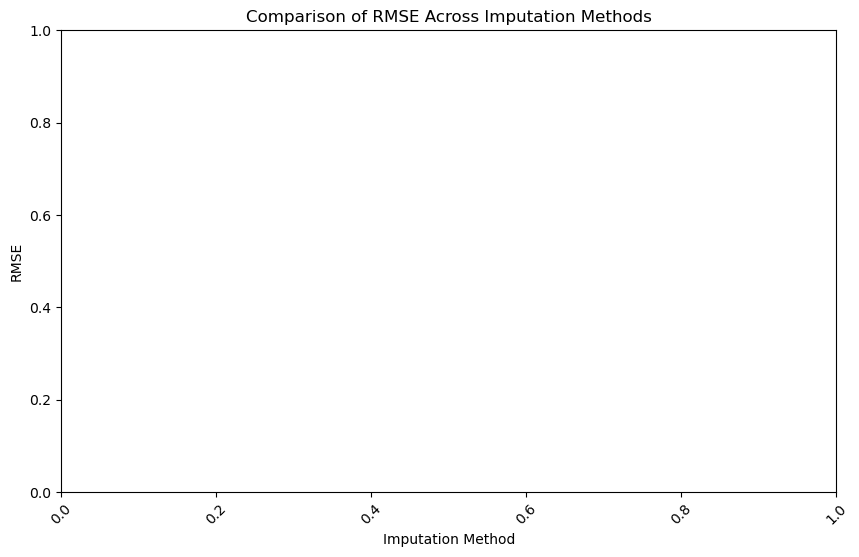

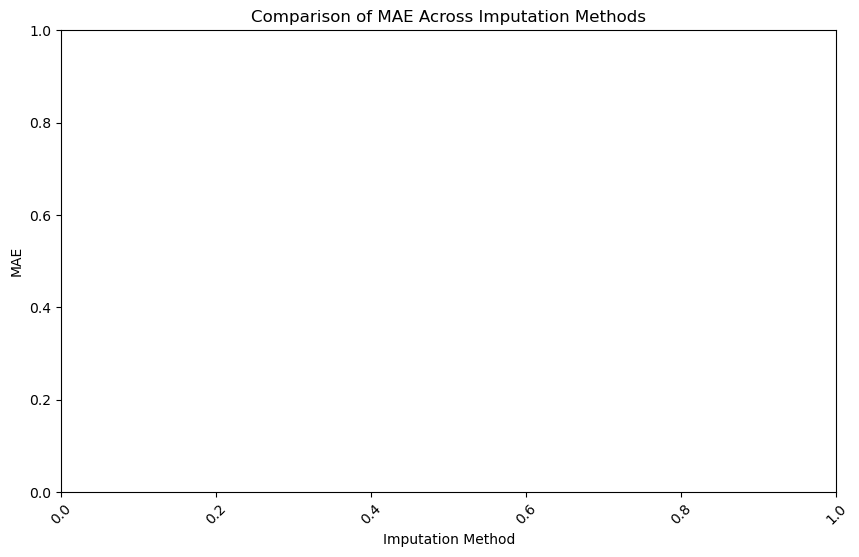

C:\Users\oxije\AppData\Local\Temp\ipykernel_37044\4072347212.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


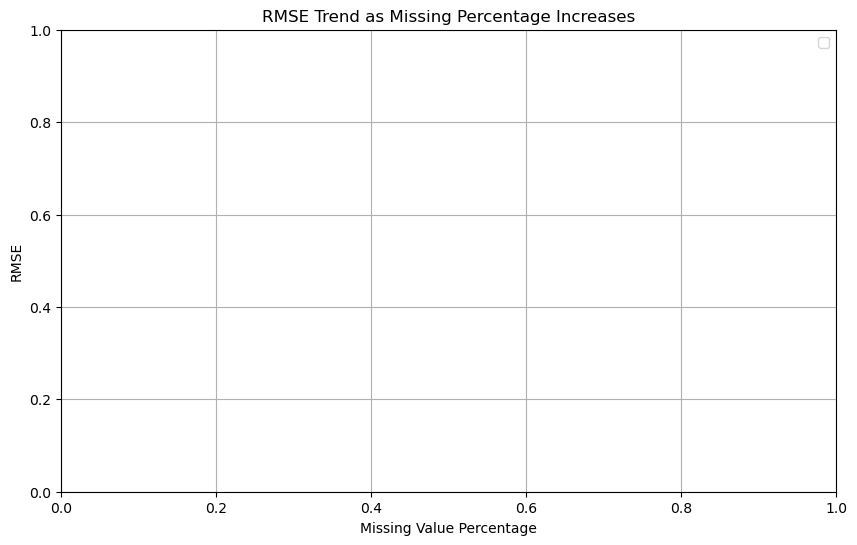

C:\Users\oxije\AppData\Local\Temp\ipykernel_37044\4072347212.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


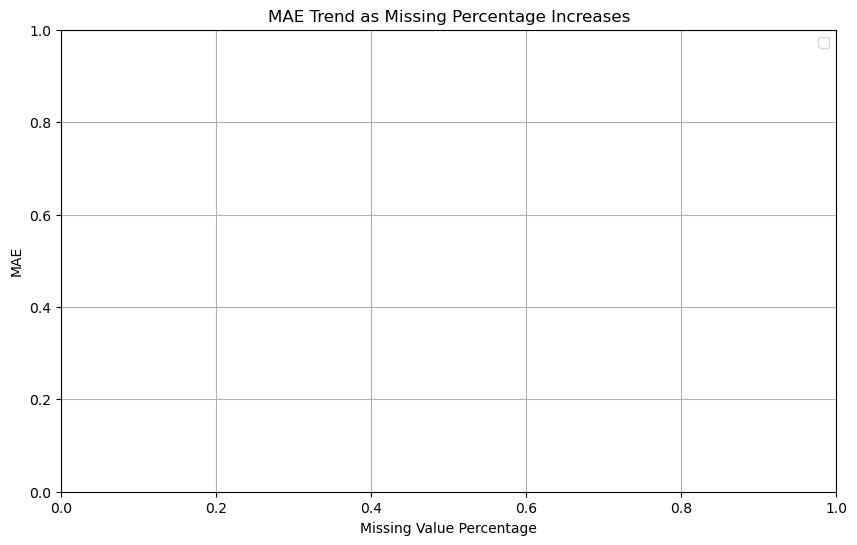

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up the dataset path
dataset_dir = r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv"  # Update with your actual path
evaluation_results_path = os.path.join(dataset_dir, "imputation_evaluation_results.csv")

# Load the evaluation results
df_eval = pd.read_csv(evaluation_results_path)




# Reshape the dataframe for visualization
df_eval_long = df_eval.melt(id_vars=['Unnamed: 0'], var_name='Metric_Method', value_name='Value')
# df_eval_long[['Metric', 'Method']] = df_eval_long['Metric_Method'].str.split('_', expand=True)


print(df_eval_long['Metric_Method'].unique())  # Check unique values before splitting


df_eval_long['Metric'] = df_eval_long['Metric_Method'].apply(lambda x: x.split('_')[0] if '_' in str(x) else x)
df_eval_long['Method'] = df_eval_long['Metric_Method'].apply(lambda x: x.split('_')[1] if '_' in str(x) else "Unknown")



# Filter RMSE and MAE separately
df_rmse = df_eval_long[df_eval_long['Metric'] == 'RMSE']
df_mae = df_eval_long[df_eval_long['Metric'] == 'MAE']

# Plot RMSE for different imputation methods
plt.figure(figsize=(10, 6))
sns.boxplot(x='Method', y='Value', data=df_rmse)
plt.title('Comparison of RMSE Across Imputation Methods')
plt.ylabel('RMSE')
plt.xlabel('Imputation Method')
plt.xticks(rotation=45)
plt.show()

# Plot MAE for different imputation methods
plt.figure(figsize=(10, 6))
sns.boxplot(x='Method', y='Value', data=df_mae)
plt.title('Comparison of MAE Across Imputation Methods')
plt.ylabel('MAE')
plt.xlabel('Imputation Method')
plt.xticks(rotation=45)
plt.show()

# Line plot: RMSE vs. Missing Percentage
df_rmse_trend = df_rmse.pivot_table(index='Unnamed: 0', columns='Method', values='Value')

plt.figure(figsize=(10, 6))
for method in df_rmse_trend.columns:
    plt.plot(df_rmse_trend.index, df_rmse_trend[method], marker='o', label=method)

plt.title('RMSE Trend as Missing Percentage Increases')
plt.xlabel('Missing Value Percentage')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

# Line plot: MAE vs. Missing Percentage
df_mae_trend = df_mae.pivot_table(index='Unnamed: 0', columns='Method', values='Value')

plt.figure(figsize=(10, 6))
for method in df_mae_trend.columns:
    plt.plot(df_mae_trend.index, df_mae_trend[method], marker='o', label=method)

plt.title('MAE Trend as Missing Percentage Increases')
plt.xlabel('Missing Value Percentage')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\2118517154.py:17: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=df, x="Missing Level", y="RMSE", hue="Method", palette=palette)


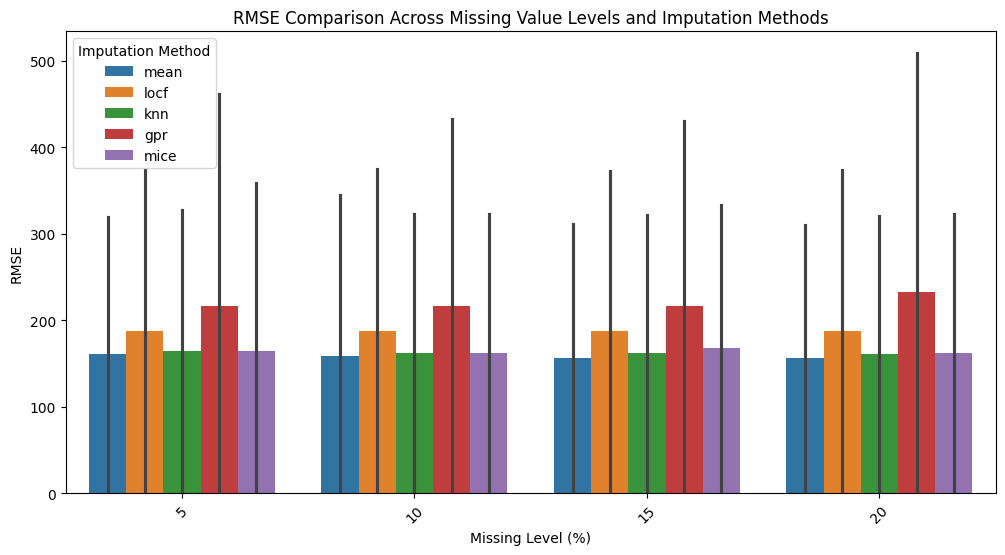

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\2118517154.py:27: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.boxplot(data=df, x="Feature", y="MAE", hue="Method", palette=palette)


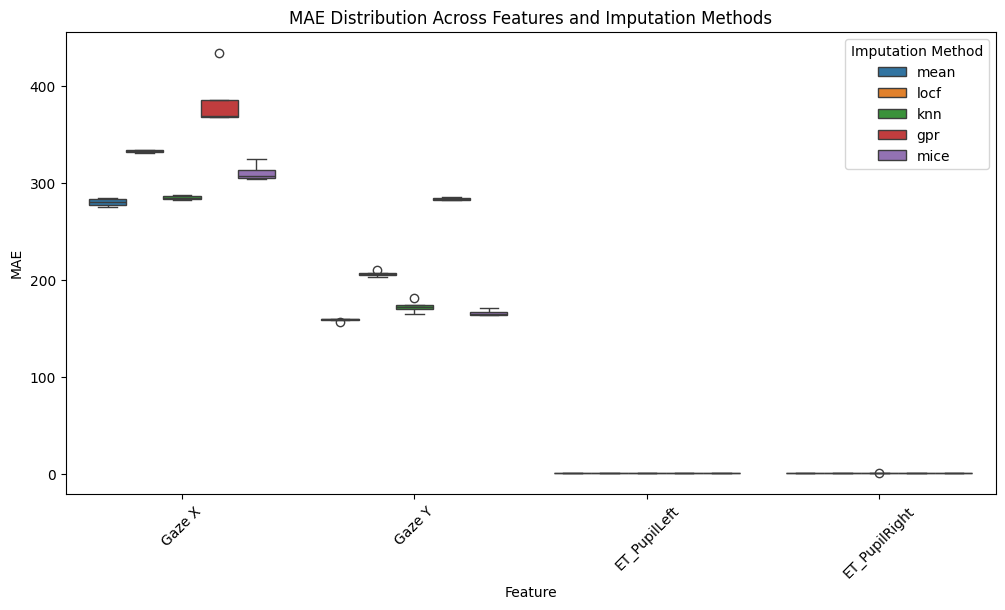

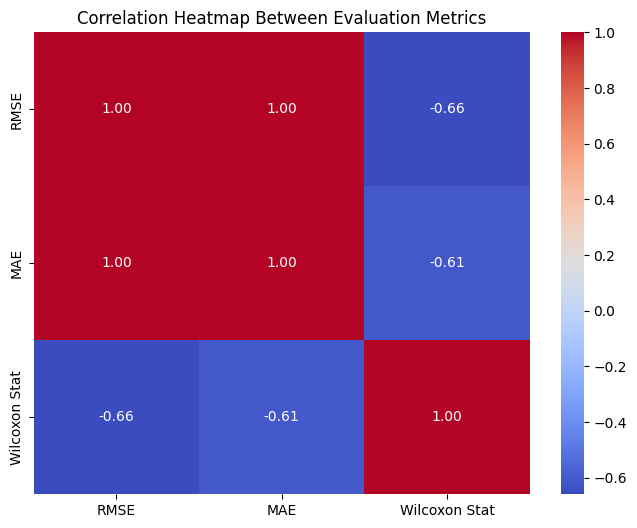

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\2118517154.py:46: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.lineplot(data=df, x="Missing Level", y="RMSE", hue="Method", marker="o", palette=palette)


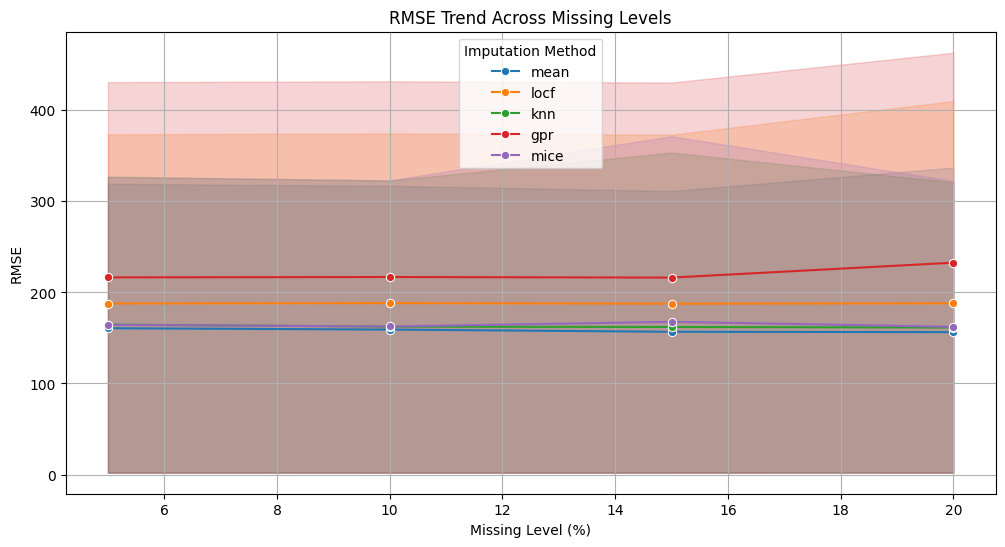

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datei einlesen
file_path = "mv_impute/imputation_evaluation_summary.xlsx"
df = pd.read_excel(file_path)

# Spaltennamen bereinigen
df.columns = df.columns.str.strip()

# Farben für die Visualisierungen definieren
palette = sns.color_palette("tab10")

# 1. Balkendiagramm: Vergleich der RMSE-Werte für verschiedene Imputationsmethoden, gruppiert nach Missing-Value-Level
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Missing Level", y="RMSE", hue="Method", palette=palette)
plt.title("RMSE Comparison Across Missing Value Levels and Imputation Methods")
plt.xlabel("Missing Level (%)")
plt.ylabel("RMSE")
plt.legend(title="Imputation Method")
plt.xticks(rotation=45)
plt.show()

# 2. Boxplot: Vergleich der MAE-Werte pro Feature
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Feature", y="MAE", hue="Method", palette=palette)
plt.title("MAE Distribution Across Features and Imputation Methods")
plt.xlabel("Feature")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.legend(title="Imputation Method")
plt.show()

# 3. Heatmap: Korrelation zwischen RMSE, MAE, Wilcoxon-Statistik
correlation_features = ["RMSE", "MAE", "Wilcoxon Stat"]
correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Between Evaluation Metrics")
plt.show()

# 4. Liniendiagramm: Entwicklung des RMSE-Werts über die Missing-Value-Level für jede Methode
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Missing Level", y="RMSE", hue="Method", marker="o", palette=palette)
plt.title("RMSE Trend Across Missing Levels")
plt.xlabel("Missing Level (%)")
plt.ylabel("RMSE")
plt.legend(title="Imputation Method")
plt.grid(True)
plt.show()


C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Method", y="RMSE", data=df, ci=None, palette=palette)
C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="RMSE", data=df, ci=None, palette=palette)


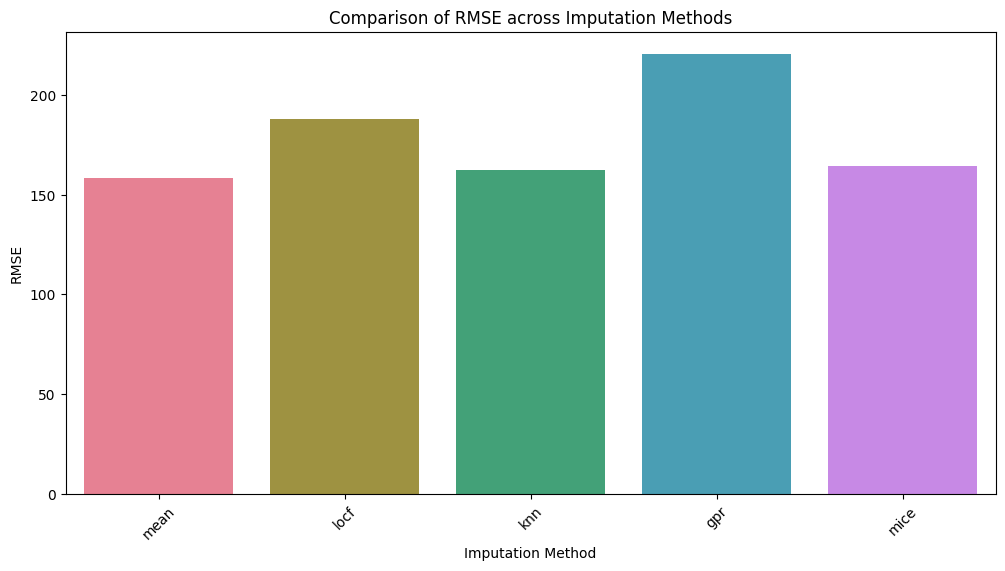

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Method", y="MAE", data=df, ci=None, palette=palette)
C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="MAE", data=df, ci=None, palette=palette)


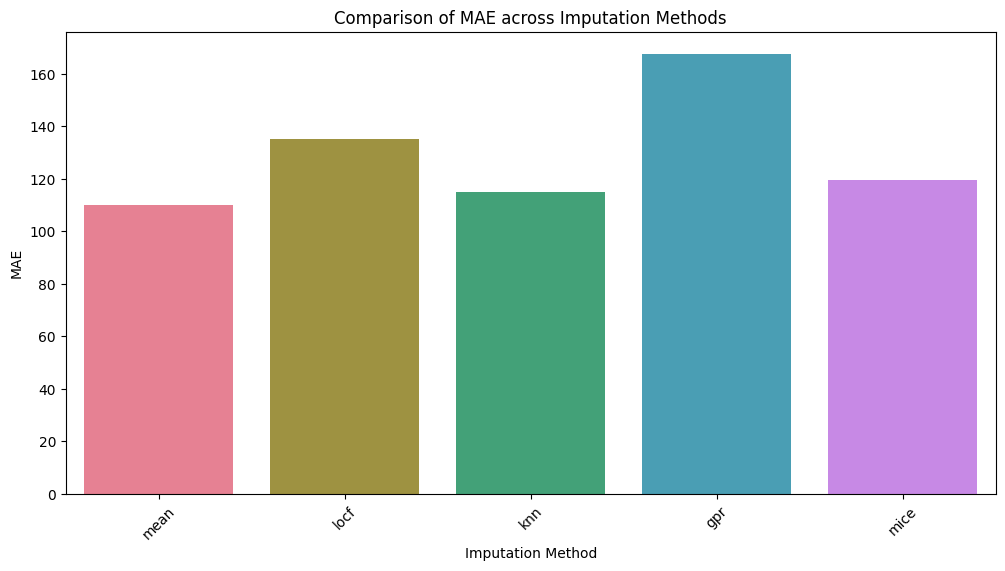

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Method", y="RMSE", data=df, palette=palette)


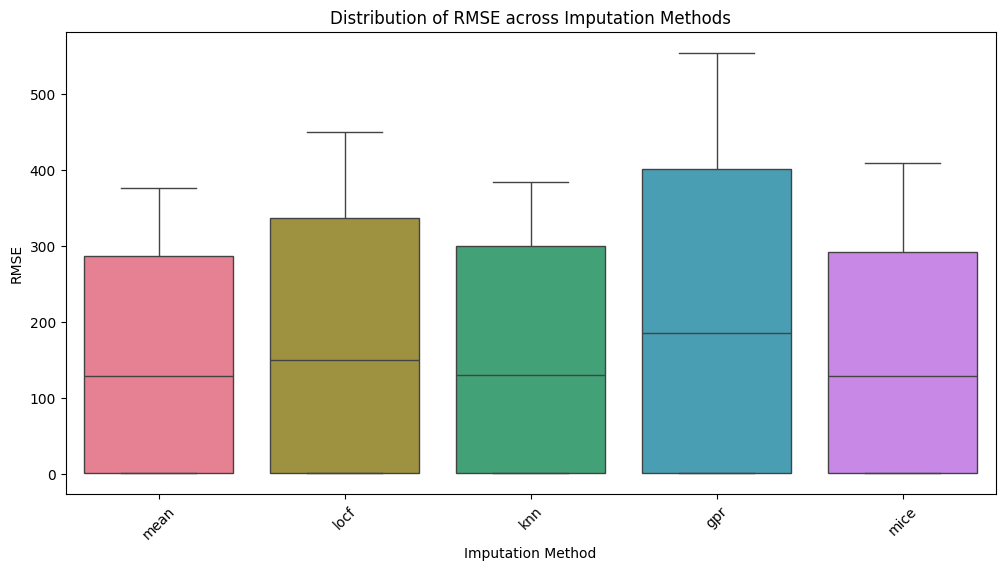

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Method", y="MAE", data=df, palette=palette)


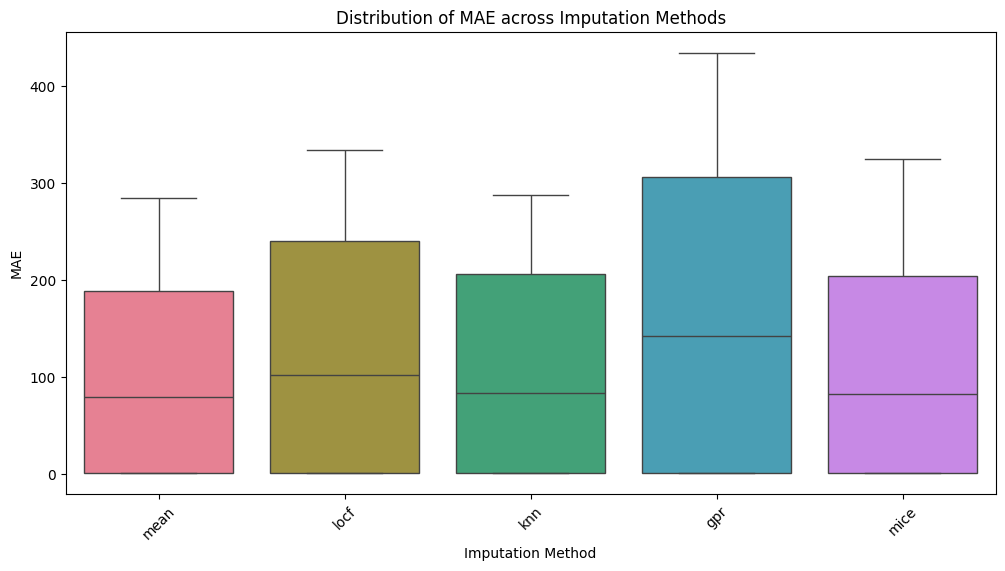

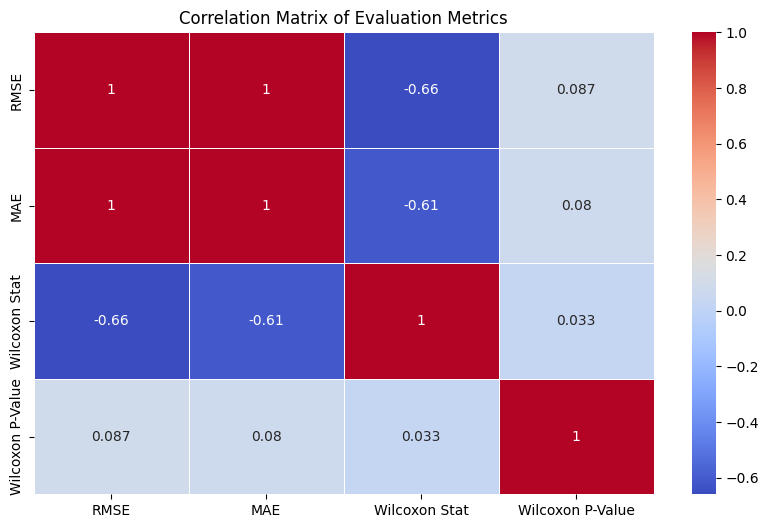

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Method", y="RMSE", data=df, palette=palette)


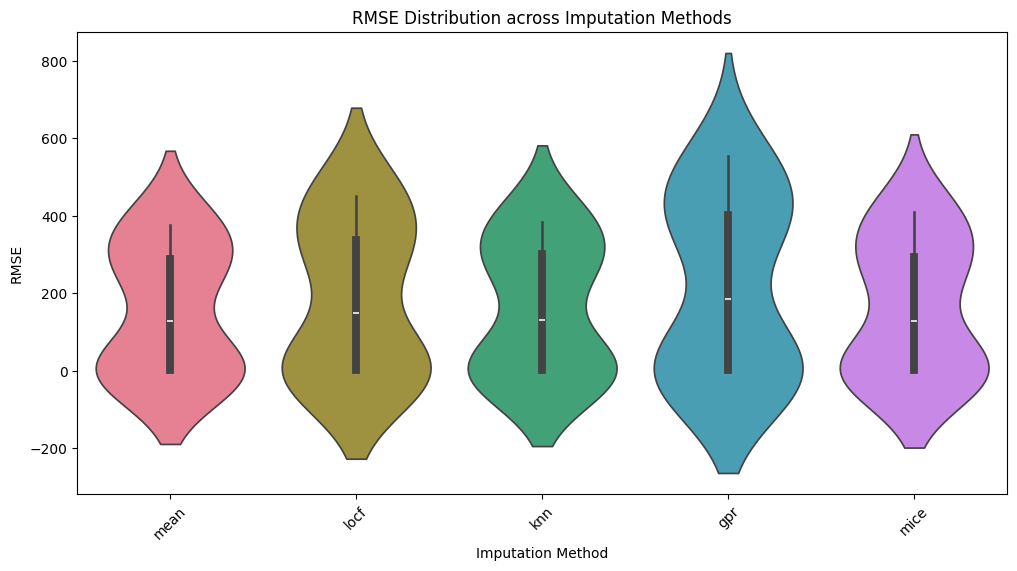

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3505241603.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Method", y="MAE", data=df, palette=palette)


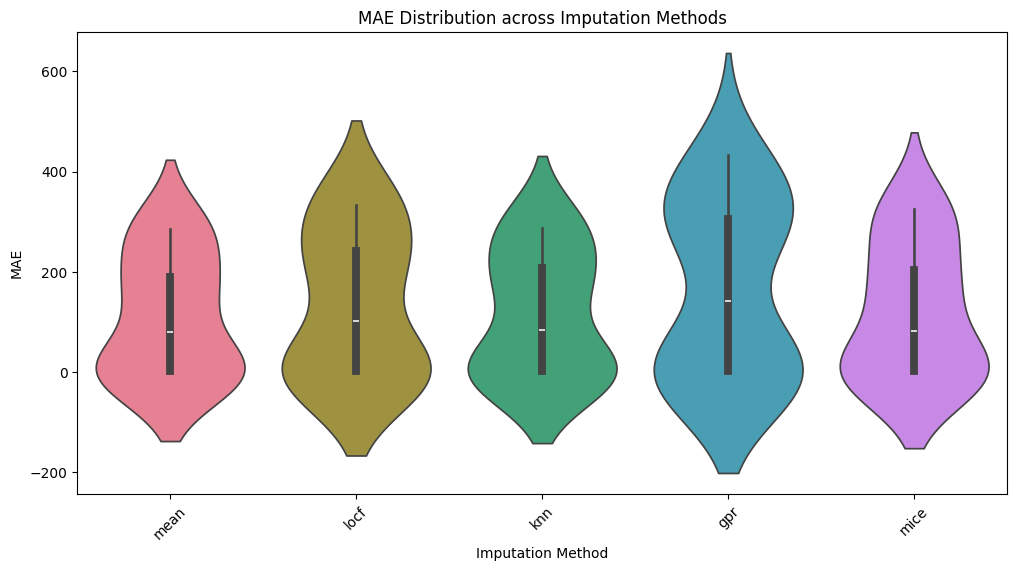

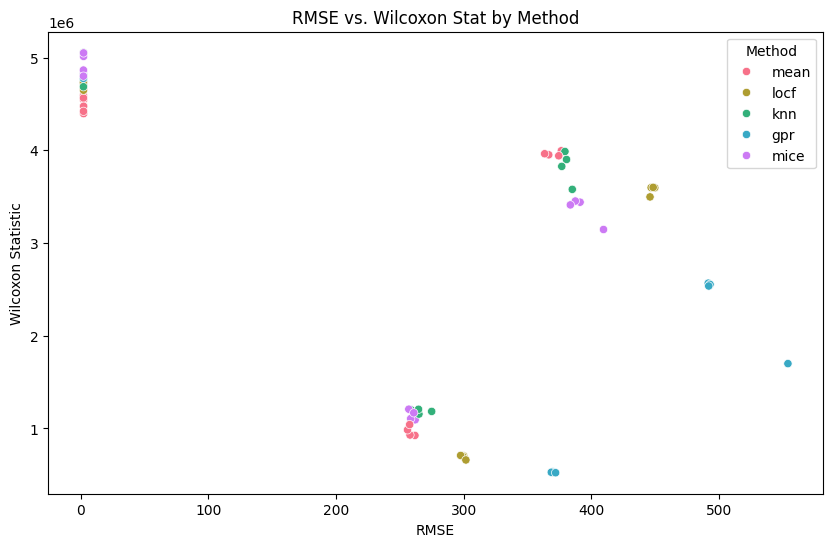

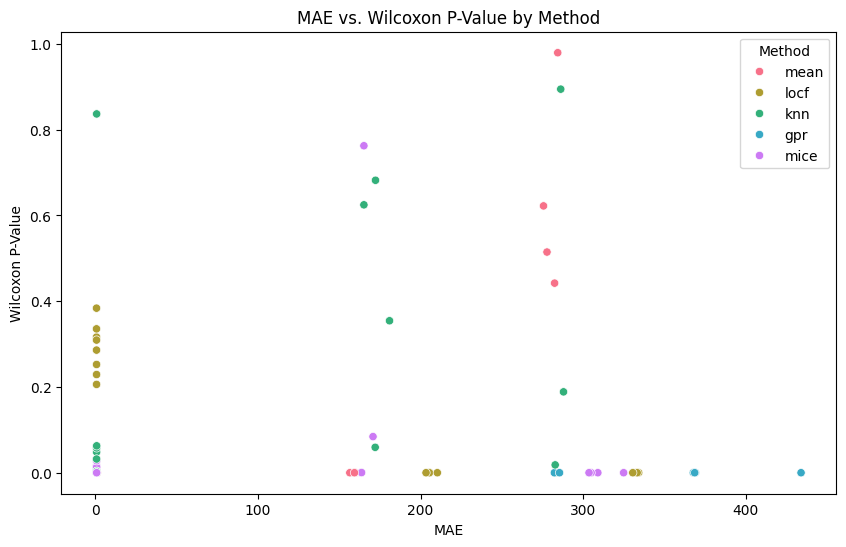

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datei laden
file_path = "mv_impute/imputation_evaluation_summary.xlsx"
df = pd.read_excel(file_path)

# Entferne mögliche Whitespaces in Spaltennamen
df.columns = df.columns.str.strip()

# Farbpalette
palette = sns.color_palette("husl", len(df["Method"].unique()))

# Balkendiagramm: RMSE nach Methode
plt.figure(figsize=(12, 6))
sns.barplot(x="Method", y="RMSE", data=df, ci=None, palette=palette)
plt.xticks(rotation=45)
plt.title("Comparison of RMSE across Imputation Methods")
plt.ylabel("RMSE")
plt.xlabel("Imputation Method")
plt.show()

# Balkendiagramm: MAE nach Methode
plt.figure(figsize=(12, 6))
sns.barplot(x="Method", y="MAE", data=df, ci=None, palette=palette)
plt.xticks(rotation=45)
plt.title("Comparison of MAE across Imputation Methods")
plt.ylabel("MAE")
plt.xlabel("Imputation Method")
plt.show()

# Boxplot: RMSE nach Methode gruppiert
plt.figure(figsize=(12, 6))
sns.boxplot(x="Method", y="RMSE", data=df, palette=palette)
plt.xticks(rotation=45)
plt.title("Distribution of RMSE across Imputation Methods")
plt.ylabel("RMSE")
plt.xlabel("Imputation Method")
plt.show()

# Boxplot: MAE nach Methode gruppiert
plt.figure(figsize=(12, 6))
sns.boxplot(x="Method", y="MAE", data=df, palette=palette)
plt.xticks(rotation=45)
plt.title("Distribution of MAE across Imputation Methods")
plt.ylabel("MAE")
plt.xlabel("Imputation Method")
plt.show()

# Heatmap zur Untersuchung der Korrelation zwischen den Metriken
plt.figure(figsize=(10, 6))
sns.heatmap(df[["RMSE", "MAE", "Wilcoxon Stat", "Wilcoxon P-Value"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Evaluation Metrics")
plt.show()

# Violinplot für RMSE
plt.figure(figsize=(12, 6))
sns.violinplot(x="Method", y="RMSE", data=df, palette=palette)
plt.xticks(rotation=45)
plt.title("RMSE Distribution across Imputation Methods")
plt.ylabel("RMSE")
plt.xlabel("Imputation Method")
plt.show()

# Violinplot für MAE
plt.figure(figsize=(12, 6))
sns.violinplot(x="Method", y="MAE", data=df, palette=palette)
plt.xticks(rotation=45)
plt.title("MAE Distribution across Imputation Methods")
plt.ylabel("MAE")
plt.xlabel("Imputation Method")
plt.show()

# Scatterplot: RMSE vs. Wilcoxon Stat
plt.figure(figsize=(10, 6))
sns.scatterplot(x="RMSE", y="Wilcoxon Stat", hue="Method", data=df, palette=palette)
plt.title("RMSE vs. Wilcoxon Stat by Method")
plt.xlabel("RMSE")
plt.ylabel("Wilcoxon Statistic")
plt.legend(title="Method")
plt.show()

# Scatterplot: MAE vs. Wilcoxon P-Value
plt.figure(figsize=(10, 6))
sns.scatterplot(x="MAE", y="Wilcoxon P-Value", hue="Method", data=df, palette=palette)
plt.title("MAE vs. Wilcoxon P-Value by Method")
plt.xlabel("MAE")
plt.ylabel("Wilcoxon P-Value")
plt.legend(title="Method")
plt.show()


C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\2019857285.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Missing Level", y="RMSE", hue="Method", data=df, ci=None, palette=palette)


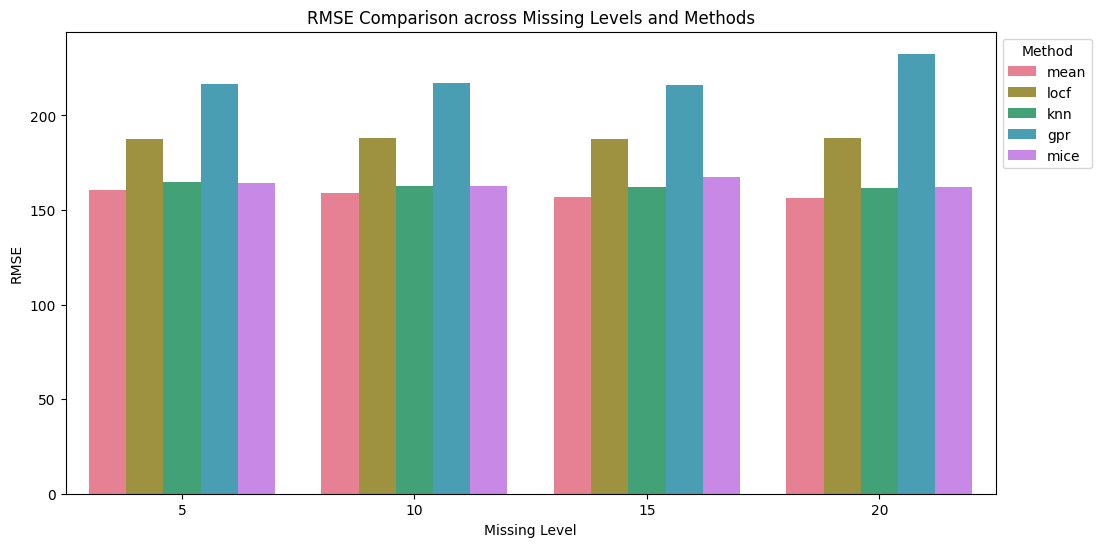

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\2019857285.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Missing Level", y="MAE", hue="Method", data=df, ci=None, palette=palette)


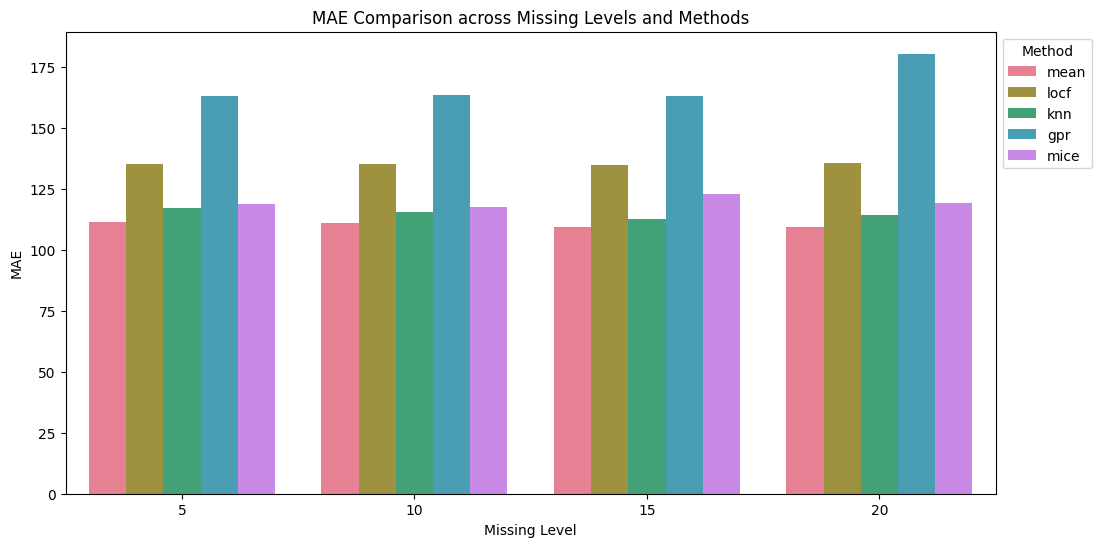

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Missing Level", y="RMSE", hue="Method", data=df, ci=None, palette=palette)
plt.title("RMSE Comparison across Missing Levels and Methods")
plt.ylabel("RMSE")
plt.xlabel("Missing Level")
plt.legend(title="Method", bbox_to_anchor=(1,1))
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="Missing Level", y="MAE", hue="Method", data=df, ci=None, palette=palette)
plt.title("MAE Comparison across Missing Levels and Methods")
plt.ylabel("MAE")
plt.xlabel("Missing Level")
plt.legend(title="Method", bbox_to_anchor=(1,1))
plt.show()


C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3013260207.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Feature", y="RMSE", hue="Method", data=df, ci=None, palette=palette)


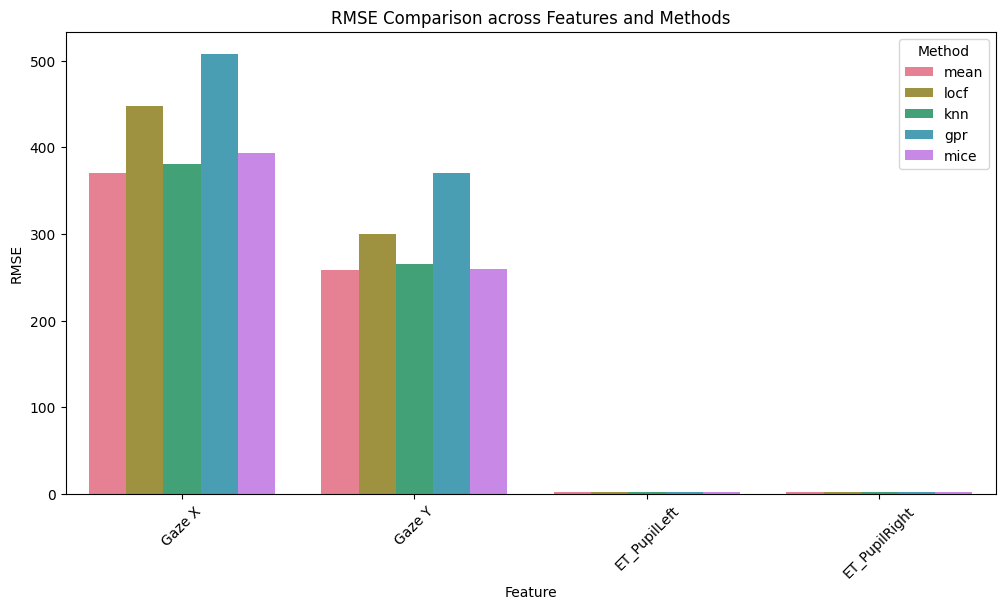

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\3013260207.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Feature", y="MAE", hue="Method", data=df, ci=None, palette=palette)


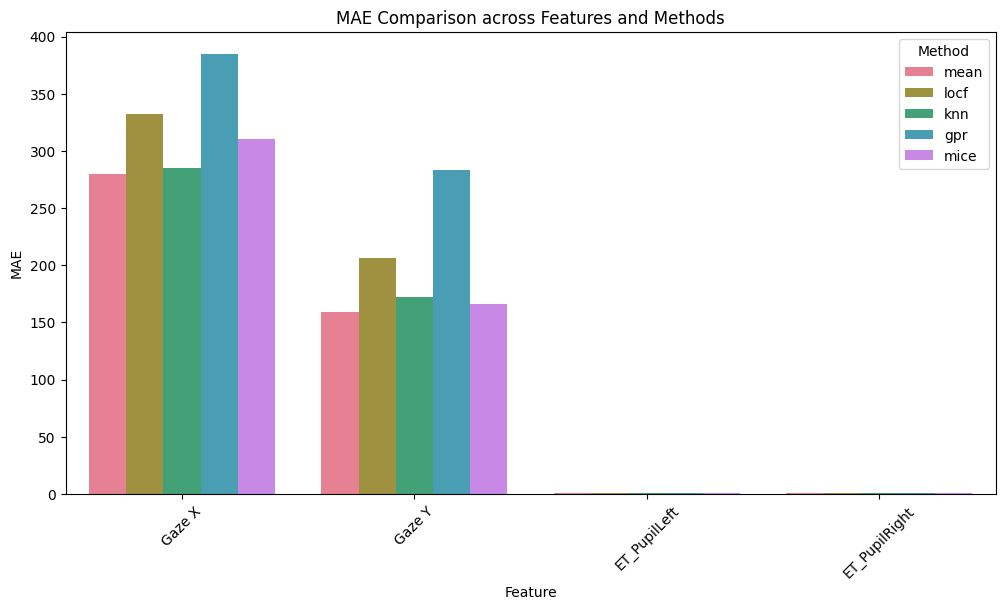

In [49]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Feature", y="RMSE", hue="Method", data=df, ci=None, palette=palette)
plt.title("RMSE Comparison across Features and Methods")
plt.ylabel("RMSE")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.legend(title="Method", bbox_to_anchor=(1,1))
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="Feature", y="MAE", hue="Method", data=df, ci=None, palette=palette)
plt.title("MAE Comparison across Features and Methods")
plt.ylabel("MAE")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.legend(title="Method", bbox_to_anchor=(1,1))
plt.show()


Outlier

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, median_abs_deviation
from sklearn.ensemble import IsolationForest
import os

# Define gaze-related columns for outlier analysis
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# List of outlier contamination levels
outlier_levels = [5, 10, 15, 20]

# Directory where datasets are stored
dataset_dir = r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv"  # Update with correct path

# Function to introduce synthetic outliers
def introduce_outliers(df, cols, outlier_percent):
    df_copy = df.copy()
    num_outliers = int(len(df_copy) * outlier_percent / 100)
    
    for col in cols:
        if col in df_copy.columns:
            outlier_indices = np.random.choice(df_copy.index, num_outliers, replace=False)
            df_copy.loc[outlier_indices, col] += np.random.uniform(5, 10) * df_copy[col].std()  # Add extreme values
    return df_copy

# Create datasets with different outlier contamination levels
for level in outlier_levels:
    dataset_path = os.path.join(dataset_dir, f"dataset_outliers_{level}.csv")
    df = pd.read_csv(os.path.join(dataset_dir, "Frage 1_001_Anonymous 09-05-23 12h04m.csv"))  # Load original dataset
    df_outliers = introduce_outliers(df, gaze_cols, level)
    df_outliers.to_csv(dataset_path, index=False)

print("Outlier simulation completed. Datasets saved.")


Outlier simulation completed. Datasets saved.


In [27]:
import numpy as np
import pandas as pd
from scipy.stats import zscore, median_abs_deviation
from sklearn.ensemble import IsolationForest
import os

def detect_outliers(df, cols, method="zscore"):
    """
    Detect and handle outliers in specified columns of a DataFrame.

    Parameters:
    - df: DataFrame containing the data.
    - cols: List of columns to check for outliers.
    - method: Method to use for outlier detection ("zscore", "mad", "isolation_forest").

    Returns:
    - DataFrame with outliers replaced by NaN.
    """
    df_copy = df.copy()
    
    for col in cols:
        if col in df_copy.columns:
            if method == "zscore":
                threshold = 3
                df_copy[col] = np.where(abs(zscore(df_copy[col])) > threshold, np.nan, df_copy[col])
            
            elif method == "mad":
                threshold = 3
                mad = median_abs_deviation(df_copy[col].dropna())
                median_val = np.median(df_copy[col].dropna())
                df_copy[col] = np.where(abs(df_copy[col] - median_val) > threshold * mad, np.nan, df_copy[col])
            
            elif method == "isolation_forest":
                # Track indices of non-missing values
                non_missing_idx = df_copy[col].notna()
                non_missing_values = df_copy[col][non_missing_idx].values.reshape(-1, 1)
                
                # Fit Isolation Forest on non-missing values
                iso_forest = IsolationForest(contamination=0.05, random_state=42)
                outliers = iso_forest.fit_predict(non_missing_values)
                
                # Map outlier predictions back to the original column
                df_copy.loc[non_missing_idx, col] = np.where(outliers == -1, np.nan, non_missing_values.flatten())

    return df_copy

# Apply outlier detection to all datasets
outlier_levels = [5, 10, 15, 20]
dataset_dir = 'C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv'
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

for level in outlier_levels:
    dataset_path = os.path.join(dataset_dir, f"dataset_outliers_{level}.csv")
    
    # Check if the file exists
    if not os.path.exists(dataset_path):
        print(f"File not found: {dataset_path}. Skipping...")
        continue  # Skip this file and move to the next level
    
    df_outliers = pd.read_csv(dataset_path)
    
    # Check if all columns exist in the DataFrame
    missing_cols = [col for col in gaze_cols if col not in df_outliers.columns]
    if missing_cols:
        print(f"Columns {missing_cols} not found in {dataset_path}. Skipping...")
        continue
    
    # Detect and handle outliers
    df_zscore_cleaned = detect_outliers(df_outliers, gaze_cols, method="zscore")
    df_mad_cleaned = detect_outliers(df_outliers, gaze_cols, method="mad")
    df_iso_cleaned = detect_outliers(df_outliers, gaze_cols, method="isolation_forest")

    # Save results
    df_zscore_cleaned.to_csv(os.path.join(dataset_dir, f"dataset_outliers_cleaned_zscore_{level}.csv"), index=False)
    df_mad_cleaned.to_csv(os.path.join(dataset_dir, f"dataset_outliers_cleaned_mad_{level}.csv"), index=False)
    df_iso_cleaned.to_csv(os.path.join(dataset_dir, f"dataset_outliers_cleaned_isolationforest_{level}.csv"), index=False)

print("Outlier detection and removal completed. Cleaned datasets saved.")

Outlier detection and removal completed. Cleaned datasets saved.


c:\Users\oxije\anaconda3.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


                                Z-Score                                    \
                 Variance Reduction (%) KS-Test Statistic KS-Test P-Value   
5  Gaze X                           0.0          0.000000             1.0   
   Gaze Y                           0.0          0.000000             1.0   
   ET_PupilLeft                     0.0          0.000185             1.0   
   ET_PupilRight                    0.0          0.000000             1.0   
10 Gaze X                           0.0          0.000000             1.0   
   Gaze Y                           0.0          0.000000             1.0   
   ET_PupilLeft                     0.0          0.000185             1.0   
   ET_PupilRight                    0.0          0.000000             1.0   
15 Gaze X                           0.0          0.000000             1.0   
   Gaze Y                           0.0          0.000903             1.0   
   ET_PupilLeft                     0.0          0.000185             1.0   

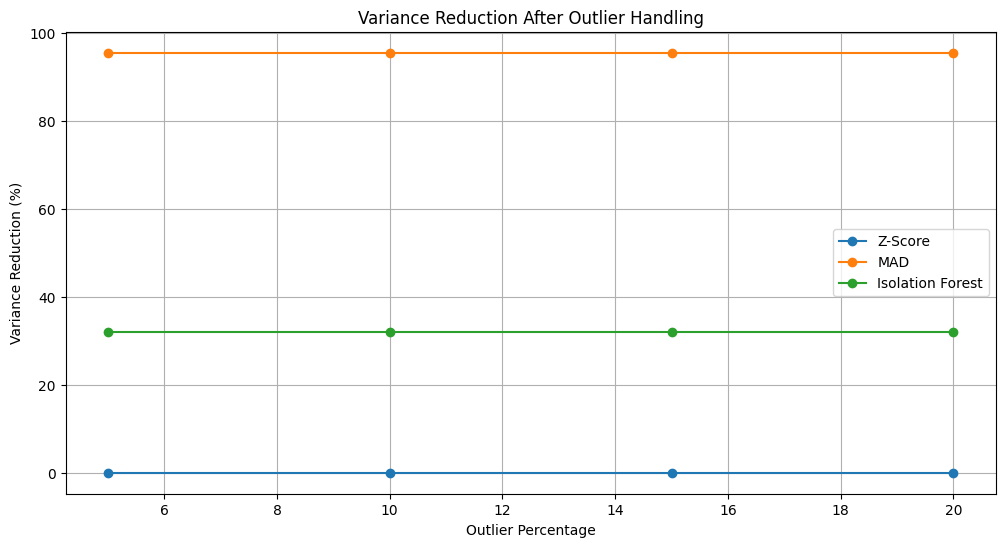

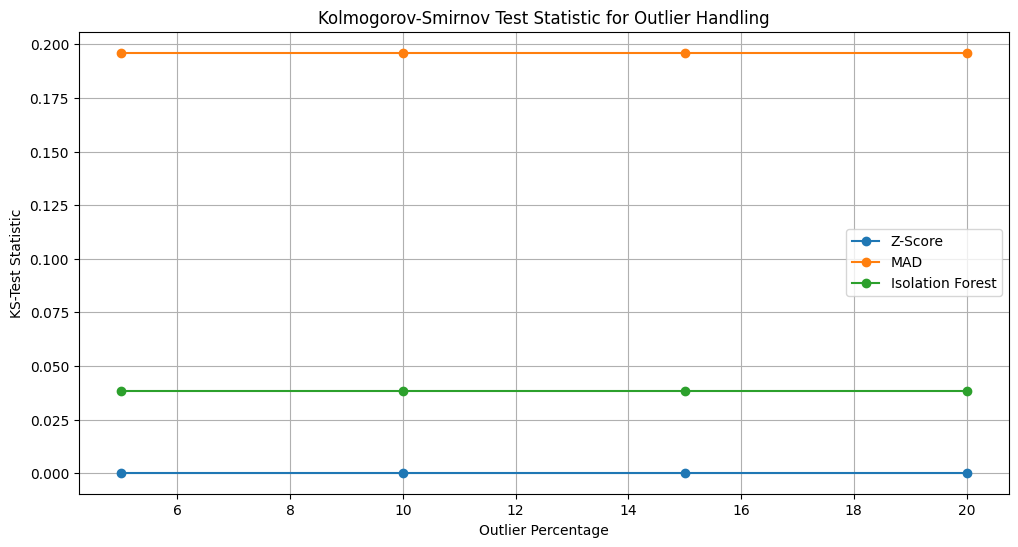

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp


# Define gaze-related columns
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# List of outlier contamination levels
outlier_levels = [5, 10, 15, 20]

# Directory where datasets are stored
dataset_dir = 'C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv' # Update with correct path

# Initialize dictionary to store evaluation results
evaluation_results = {}

# Function to compute variance and KS-Test for outlier handling methods
def evaluate_outlier_handling(original, cleaned, cols):
    results = {}
    for col in cols:
        # Compute variance reduction
        original_var = np.var(original[col].dropna())
        cleaned_var = np.var(cleaned[col].dropna())
        variance_reduction = (original_var - cleaned_var) / original_var * 100  # Percentage reduction

        # KS-Test: Compare distributions of original vs. cleaned data
        ks_stat, ks_pval = ks_2samp(original[col].dropna(), cleaned[col].dropna())

        results[col] = {
            "Variance Reduction (%)": variance_reduction,
            "KS-Test Statistic": ks_stat,
            "KS-Test P-Value": ks_pval
        }
    return pd.DataFrame(results).T

# Loop through all outlier levels
for level in outlier_levels:
    dataset_path = f"{dataset_dir}/dataset_outliers_{level}.csv"
    df_outliers = pd.read_csv(dataset_path)

    df_zscore_cleaned = pd.read_csv(f"{dataset_dir}/dataset_outliers_cleaned_zscore_{level}.csv")
    df_mad_cleaned = pd.read_csv(f"{dataset_dir}/dataset_outliers_cleaned_mad_{level}.csv")
    df_iso_cleaned = pd.read_csv(f"{dataset_dir}/dataset_outliers_cleaned_isolationforest_{level}.csv")

    # Evaluate methods
    eval_zscore = evaluate_outlier_handling(df_outliers, df_zscore_cleaned, gaze_cols)
    eval_mad = evaluate_outlier_handling(df_outliers, df_mad_cleaned, gaze_cols)
    eval_iso = evaluate_outlier_handling(df_outliers, df_iso_cleaned, gaze_cols)

    # Store results
    evaluation_results[level] = pd.concat({
        "Z-Score": eval_zscore,
        "MAD": eval_mad,
        "Isolation Forest": eval_iso
    }, axis=1)

# Combine all evaluations into one dataframe
final_eval_outliers = pd.concat(evaluation_results, axis=0)

# Display the evaluation results

print(final_eval_outliers)  # Display results in the console
final_eval_outliers.to_csv(f"{dataset_dir}/outlier_handling_evaluation_results.csv", index=True)  # Save results as CSV
print("Outlier handling evaluation results saved as 'outlier_handling_evaluation_results.csv'.")


# Visualizing Variance Reduction
plt.figure(figsize=(12, 6))
for method in ["Z-Score", "MAD", "Isolation Forest"]:
    if method in final_eval_outliers.columns:
        mean_variance_reduction = final_eval_outliers[method]["Variance Reduction (%)"].mean()
        plt.plot(outlier_levels, [mean_variance_reduction] * len(outlier_levels), marker='o', label=method)

plt.title("Variance Reduction After Outlier Handling")
plt.xlabel("Outlier Percentage")
plt.ylabel("Variance Reduction (%)")
plt.legend()
plt.grid(True)
plt.show()


# Visualizing KS-Test Statistic
plt.figure(figsize=(12, 6))
for method in ["Z-Score", "MAD", "Isolation Forest"]:
    if method in final_eval_outliers.columns:
        ks_stat_values = final_eval_outliers[method]["KS-Test Statistic"]
        mean_ks_stat = ks_stat_values.mean()
        plt.plot(outlier_levels, [mean_ks_stat] * len(outlier_levels), marker='o', label=method)

plt.title("Kolmogorov-Smirnov Test Statistic for Outlier Handling")
plt.xlabel("Outlier Percentage")
plt.ylabel("KS-Test Statistic")
plt.legend()
plt.grid(True)
plt.show()




In [35]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, wilcoxon
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# Define file paths
base_path = r"C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/outlier_impute/"

# List of outlier contamination levels
outlier_levels = [5, 10, 15, 20]

# Define outlier detection methods
outlier_methods = ["zscore", "mad", "isolationforest"]

# Load original dataset
original_file = os.path.join(base_path, "Frage 1_001_Anonymous 09-05-23 12h04m.csv")
df_original = pd.read_csv(original_file)

# Define gaze-related columns
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# Dictionary to store evaluation results
evaluation_results = []
comparison_results = {}

# Loop through outlier levels
for level in outlier_levels:
    dataset_path = os.path.join(base_path, f"dataset_outliers_{level}.csv")
    df_outliers = pd.read_csv(dataset_path)
    
    imputed_data = {col: df_original[col].copy() for col in gaze_cols}  # Start with original values
    
    for method in outlier_methods:
        cleaned_file = os.path.join(base_path, f"dataset_outliers_cleaned_{method}_{level}.csv")
        df_cleaned = pd.read_csv(cleaned_file)
        
        for col in gaze_cols:
            if col in df_cleaned.columns:
                imputed_data[f"{col}_{method}"] = df_cleaned[col]
        
        # Evaluate outlier removal effectiveness
        for col in gaze_cols:
            if col in df_cleaned.columns:
                original_values = df_outliers[col].dropna()
                cleaned_values = df_cleaned[col].dropna()
                
                # Check if Wilcoxon test is possible (data must not be identical)
                try:
                    if not np.array_equal(original_values, cleaned_values) and len(original_values) > 0 and len(cleaned_values) > 0:
                        wilcoxon_stat, wilcoxon_p = wilcoxon(original_values, cleaned_values)
                    else:
                        wilcoxon_stat, wilcoxon_p = np.nan, np.nan
                except ValueError:
                    wilcoxon_stat, wilcoxon_p = np.nan, np.nan
                
                eval_results = {
                    "Variance Reduction (%)": (np.var(original_values) - np.var(cleaned_values)) if len(original_values) > 0 and len(cleaned_values) > 0 else np.nan,
                    "KS-Test Statistic": ks_2samp(original_values, cleaned_values).statistic if len(original_values) > 0 and len(cleaned_values) > 0 else np.nan,
                    "KS-Test P-Value": ks_2samp(original_values, cleaned_values).pvalue if len(original_values) > 0 and len(cleaned_values) > 0 else np.nan,
                    "Wilcoxon Stat": wilcoxon_stat,
                    "Wilcoxon P-Value": wilcoxon_p
                }
                evaluation_results.append({
                    "Outlier Level": level,
                    "Feature": col,
                    "Method": method,
                    **eval_results
                })
    
    # Create a DataFrame for the comparison
    df_comparison = pd.DataFrame(imputed_data)
    
    # Save comparison results to an Excel file
    comparison_file = os.path.join(base_path, f"outlier_comparison_{level}.xlsx")
    df_comparison.to_excel(comparison_file, index=False)
    
    print(f"Saved comparison file: {comparison_file}")

# Convert to DataFrame and save as Excel
eval_df = pd.DataFrame(evaluation_results)
eval_file = os.path.join(base_path, "outlier_detection_evaluation.xlsx")
eval_df.to_excel(eval_file, index=False)

print(f"Evaluation summary saved as {eval_file}")

Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/outlier_impute/outlier_comparison_5.xlsx
Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/outlier_impute/outlier_comparison_10.xlsx


c:\Users\oxije\anaconda3.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/outlier_impute/outlier_comparison_15.xlsx
Saved comparison file: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/outlier_impute/outlier_comparison_20.xlsx
Evaluation summary saved as C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/outlier_impute/outlier_detection_evaluation.xlsx


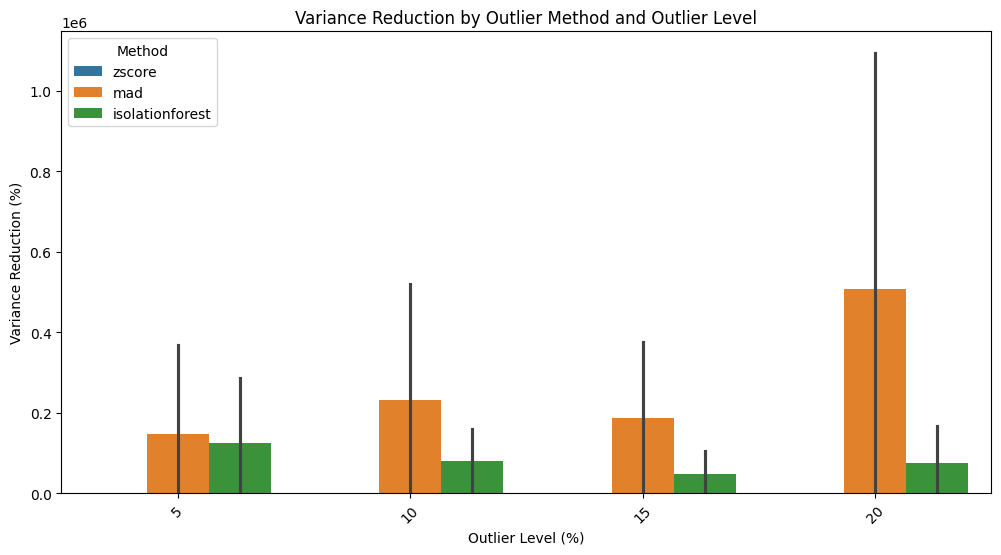

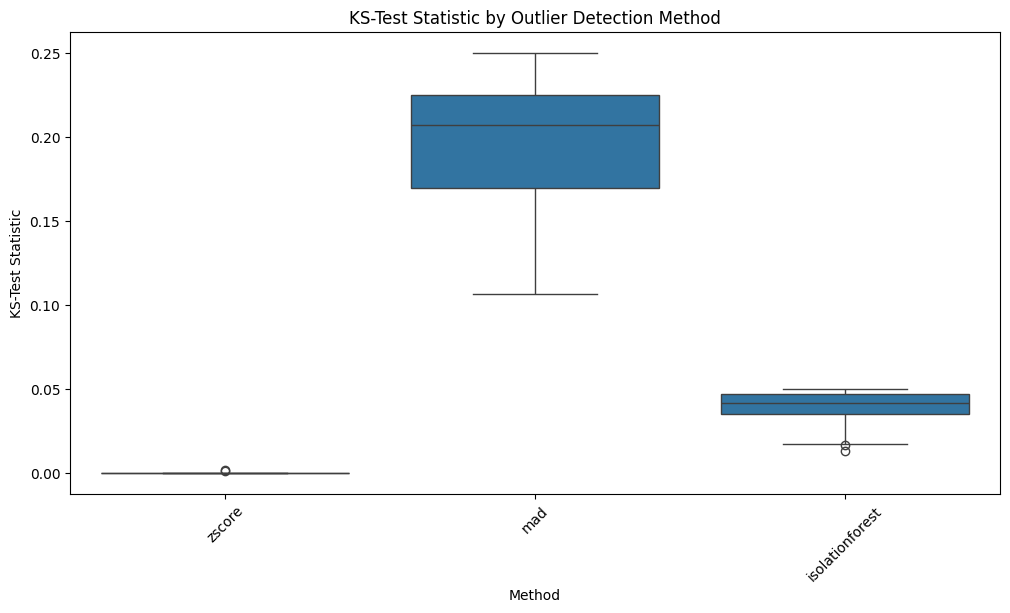

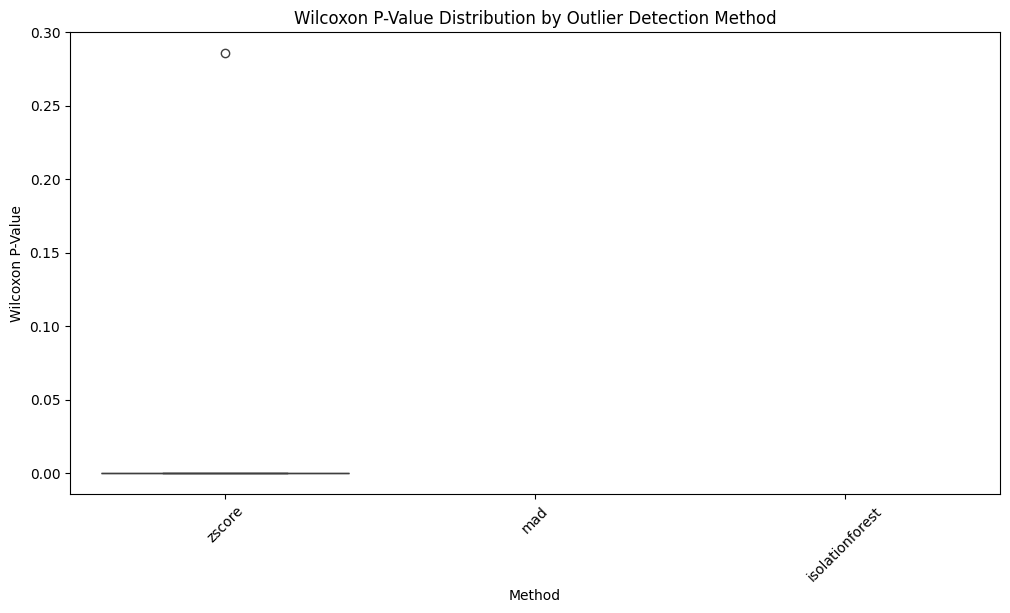

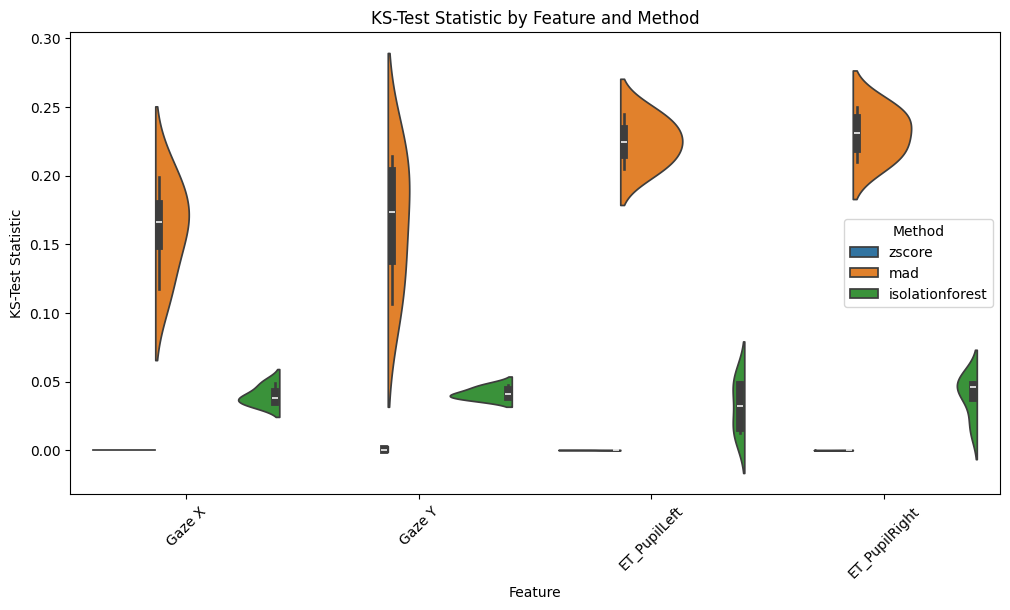

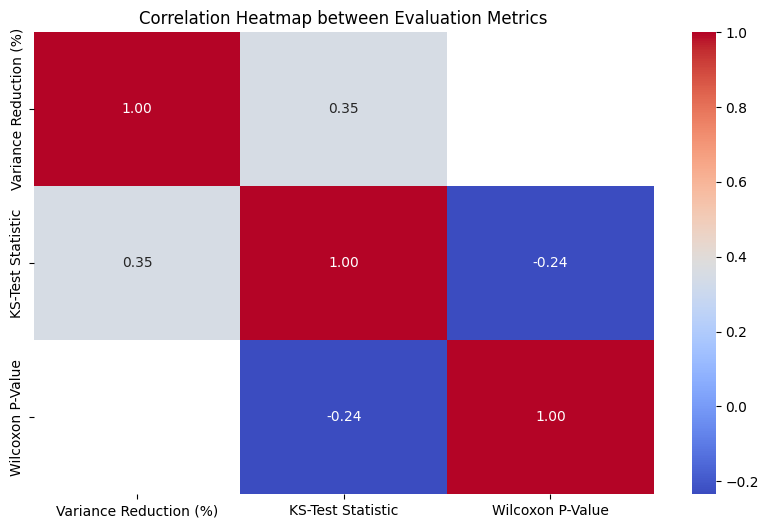

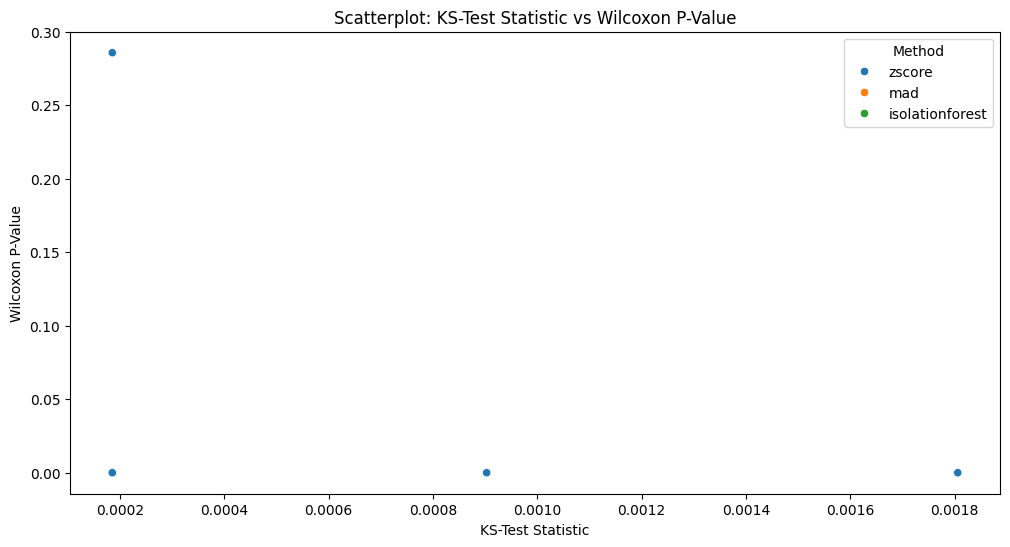

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lade die Datei
file_path = "outlier_impute/outlier_detection_evaluation.xlsx"
df_outliers = pd.read_excel(file_path)

# Konvertiere Spaltennamen in einheitliches Format
df_outliers.columns = df_outliers.columns.str.strip()

# Erstelle verschiedene Diagramme zur Visualisierung der Outlier-Detection-Ergebnisse

# 1. Balkendiagramm: Vergleich der Variance Reduction nach Methode und Outlier Level
plt.figure(figsize=(12, 6))
sns.barplot(data=df_outliers, x="Outlier Level", y="Variance Reduction (%)", hue="Method")
plt.title("Variance Reduction by Outlier Method and Outlier Level")
plt.xlabel("Outlier Level (%)")
plt.ylabel("Variance Reduction (%)")
plt.legend(title="Method")
plt.xticks(rotation=45)
plt.show()

# 2. Boxplot: KS-Test Statistik nach Outlier-Erkennungsmethode
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_outliers, x="Method", y="KS-Test Statistic")
plt.title("KS-Test Statistic by Outlier Detection Method")
plt.xlabel("Method")
plt.ylabel("KS-Test Statistic")
plt.xticks(rotation=45)
plt.show()

# 3. Boxplot: Wilcoxon P-Value nach Methode
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_outliers, x="Method", y="Wilcoxon P-Value")
plt.title("Wilcoxon P-Value Distribution by Outlier Detection Method")
plt.xlabel("Method")
plt.ylabel("Wilcoxon P-Value")
plt.xticks(rotation=45)
plt.show()

# 4. Violinplot: KS-Test Statistic nach Feature
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_outliers, x="Feature", y="KS-Test Statistic", hue="Method", split=True)
plt.title("KS-Test Statistic by Feature and Method")
plt.xlabel("Feature")
plt.ylabel("KS-Test Statistic")
plt.xticks(rotation=45)
plt.show()

# 5. Heatmap: Korrelation zwischen Variance Reduction, KS-Test Statistic und Wilcoxon P-Value
plt.figure(figsize=(10, 6))
sns.heatmap(df_outliers[["Variance Reduction (%)", "KS-Test Statistic", "Wilcoxon P-Value"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap between Evaluation Metrics")
plt.show()

# 6. Scatterplot: Vergleich zwischen KS-Test Statistic und Wilcoxon P-Value
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_outliers, x="KS-Test Statistic", y="Wilcoxon P-Value", hue="Method")
plt.title("Scatterplot: KS-Test Statistic vs Wilcoxon P-Value")
plt.xlabel("KS-Test Statistic")
plt.ylabel("Wilcoxon P-Value")
plt.show()


Normalisierung

In [17]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from scipy.stats import ks_2samp

# Originaldatensatz
file_path = "C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/Frage 1_001_Anonymous 09-05-23 12h04m.csv"
df = pd.read_csv(file_path)

# Relevante Spalten für die Verarbeitung
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# 1. Missing-Value-Imputation mit KNN
imputer = KNNImputer(n_neighbors=5)
df[gaze_cols] = imputer.fit_transform(df[gaze_cols])
print("Missing values imputed using KNN.")

# 2. Ausreißererkennung mit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(df[gaze_cols])
df = df[outlier_labels == 1]  # Nur normale Werte behalten
print("Outliers removed using Isolation Forest.")

# 3. Normalisierungsmethoden testen
normalization_methods = {
    "minmax": MinMaxScaler(),
    "zscore": StandardScaler(),
    "robust": RobustScaler()
}

# Dataframe für Evaluierungsergebnisse
evaluation_results = []

# Originalmetriken berechnen
original_variance = df[gaze_cols].var()
original_skewness = df[gaze_cols].skew()
original_kurtosis = df[gaze_cols].kurtosis()

# Speichert normalisierte Versionen und berechnet Evaluierungsmethoden
for method, scaler in normalization_methods.items():
    df_normalized = df.copy()
    df_normalized[gaze_cols] = scaler.fit_transform(df[gaze_cols])
    
    # Berechnung der Metriken
    variance_reduction = 100 * (1 - (df_normalized[gaze_cols].var() / original_variance))
    skewness_reduction = 100 * (1 - (df_normalized[gaze_cols].skew() / original_skewness))
    kurtosis_reduction = 100 * (1 - (df_normalized[gaze_cols].kurtosis() / original_kurtosis))
    ks_stats = [ks_2samp(df[col], df_normalized[col]).statistic for col in gaze_cols]
    ks_pvals = [ks_2samp(df[col], df_normalized[col]).pvalue for col in gaze_cols]
    
    # Ergebnisse speichern
    evaluation_results.append({
        "Method": method,
        "Variance Reduction (%)": variance_reduction.mean(),
        "Skewness Reduction": skewness_reduction.mean(),
        "Kurtosis Reduction": kurtosis_reduction.mean(),
        "KS-Test Statistic": np.mean(ks_stats),
        "KS-Test P-Value": np.mean(ks_pvals)
    })
    
    # Speichern der normalisierten Daten
    save_path = file_path.replace(".csv", f"_normalized_{method}.csv")
    df_normalized.to_csv(save_path, index=False)
    print(f"Saved normalized dataset: {save_path}")

# Speichern der Evaluierungsergebnisse in eine Excel-Tabelle
eval_df = pd.DataFrame(evaluation_results)
eval_df.to_excel(file_path.replace(".csv", "_evaluation.xlsx"), index=False)
print("Evaluation results saved to Excel.")

print("Processing complete.")


Missing values imputed using KNN.
Outliers removed using Isolation Forest.
Saved normalized dataset: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/Frage 1_001_Anonymous 09-05-23 12h04m_normalized_minmax.csv
Saved normalized dataset: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/Frage 1_001_Anonymous 09-05-23 12h04m_normalized_zscore.csv
Saved normalized dataset: C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/Frage 1_001_Anonymous 09-05-23 12h04m_normalized_robust.csv
Evaluation results saved to Excel.
Processing complete.


✅ Beste MV-Methode: Mean, Beste Outlier-Methode: MAD


c:\Users\oxije\anaconda3.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\oxije\anaconda3.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\oxije\anaconda3.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\oxije\anaconda3.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\oxije\anaconda3.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=

⚠ Warning: Keine validen Daten für die beste Methode gefunden!
✅ Normalization completed! Results saved.


c:\Users\oxije\anaconda3.1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


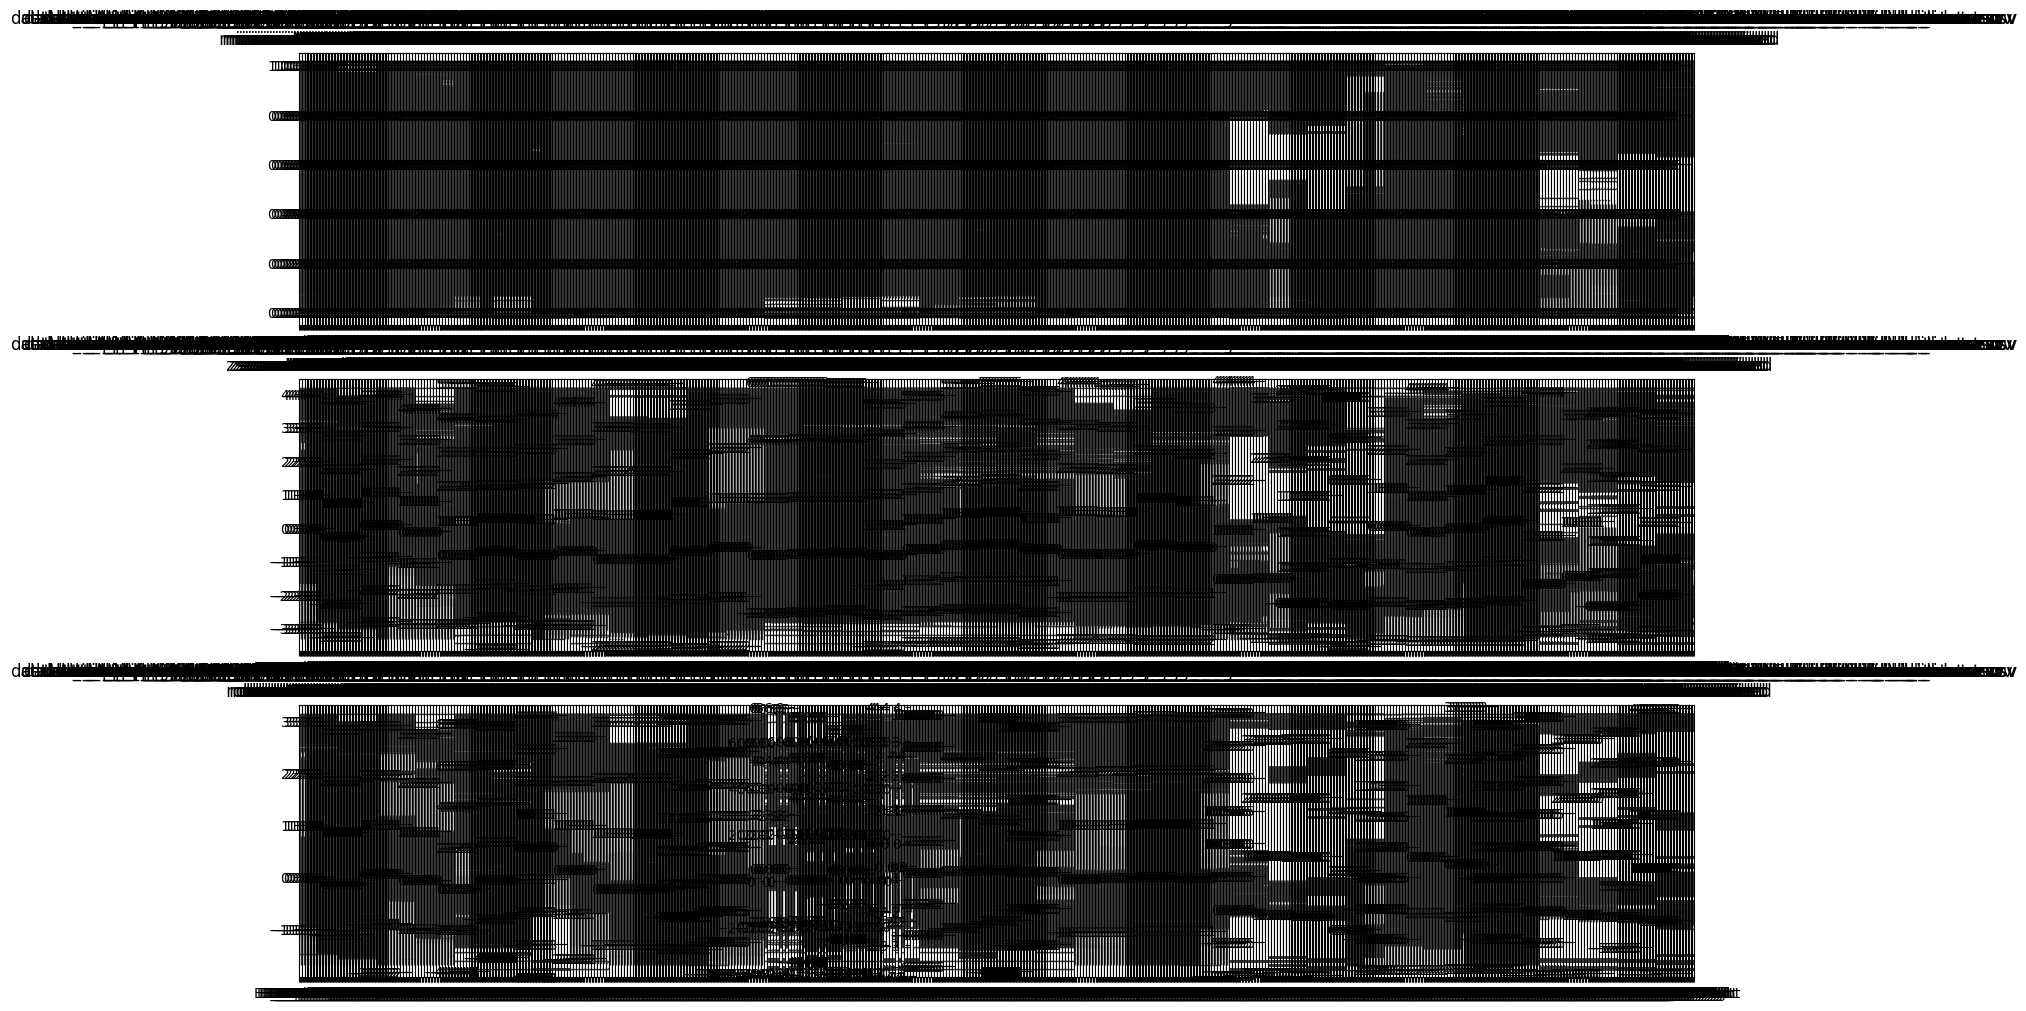

In [12]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, skew, kurtosis
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 🔹 Pfad zum Dataset-Ordner
dataset_dir = r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv"

# 🔹 Gaze-Feature-Spalten
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# 🔹 Normalisierungs-Methoden definieren
scalers = {
    "minmax": MinMaxScaler(),
    "zscore": StandardScaler(),
    "robust": RobustScaler()
}

# 🔹 Lade Evaluationsergebnisse für MV & Outlier Handling
imputation_eval_path = os.path.join(dataset_dir, "imputation_evaluation_results.csv")
outlier_eval_path = os.path.join(dataset_dir, "outlier_handling_evaluation_results.csv")

df_imputation_eval = pd.read_csv(imputation_eval_path)
df_outlier_eval = pd.read_csv(outlier_eval_path)

# 🔹 Konvertiere Strings in numerische Werte, falls vorhanden
df_imputation_eval = df_imputation_eval.apply(pd.to_numeric, errors='coerce')
df_outlier_eval = df_outlier_eval.apply(pd.to_numeric, errors='coerce')

# 🔹 Nur numerische Spalten behalten
df_imputation_eval = df_imputation_eval.dropna(axis=1, how="all")
df_outlier_eval = df_outlier_eval.dropna(axis=1, how="all")

# 🔹 Beste Methoden bestimmen (niedrigster RMSE für MV, höchster KS-Test für Outliers)
best_mv_method, best_outlier_method = None, None

if not df_imputation_eval.empty and df_imputation_eval.shape[1] > 1:
    best_mv_method_col = df_imputation_eval.mean().idxmin()
    best_mv_method = best_mv_method_col.split('_')[0] if "_" in best_mv_method_col else best_mv_method_col

if not df_outlier_eval.empty and df_outlier_eval.shape[1] > 1:
    best_outlier_method_col = df_outlier_eval.mean().idxmax()
    best_outlier_method = best_outlier_method_col.split('_')[0] if "_" in best_outlier_method_col else best_outlier_method_col

# 🔹 Falls keine Methode gefunden wurde, Standard setzen
if best_mv_method is None:
    best_mv_method = "mean"
    print("⚠ Warning: Keine MV-Methode gefunden! Standard: Mean")

if best_outlier_method is None:
    best_outlier_method = "zscore"
    print("⚠ Warning: Keine Outlier-Methode gefunden! Standard: Z-Score")

print(f"✅ Beste MV-Methode: {best_mv_method}, Beste Outlier-Methode: {best_outlier_method}")

# 🔹 Alle Dateien im Verzeichnis auflisten
all_files = os.listdir(dataset_dir)

# 🔹 Filter: Nur Dateien mit Missing-Value- oder Outlier-Handling
processed_files = [
    f for f in all_files 
    if ("imputed" in f or "outliers_cleaned" in f or "dataset_missing" in f) and f.endswith(".csv")
]

# 🔹 Evaluation-Resultat-Speicher
evaluation_results = {}

# 🔹 Iteriere über jede Datei und wende die Normalisierung an
for file in processed_files:
    file_path = os.path.join(dataset_dir, file)
    df = pd.read_csv(file_path)

    # 🔹 Sicherstellen, dass Gaze-Spalten vorhanden sind
    if not all(col in df.columns for col in gaze_cols):
        continue

    for norm_method, scaler in scalers.items():
        # 🔹 Normalisierung anwenden
        df_normalized = df.copy()
        df_normalized[gaze_cols] = scaler.fit_transform(df[gaze_cols])

        # 🔹 Datei speichern mit neuem Namen
        normalized_file_name = file.replace(".csv", f"_normalized_{norm_method}.csv")
        normalized_file_path = os.path.join(dataset_dir, normalized_file_name)
        df_normalized.to_csv(normalized_file_path, index=False)

        # 🔹 Evaluation durchführen
        eval_results = {}
        for col in gaze_cols:
            original_var = np.var(df[col].dropna())
            normalized_var = np.var(df_normalized[col].dropna())
            original_skew = skew(df[col].dropna())
            normalized_skew = skew(df_normalized[col].dropna())
            original_kurt = kurtosis(df[col].dropna())
            normalized_kurt = kurtosis(df_normalized[col].dropna())

            # KS-Test zur Verteilungsvergleichung
            ks_stat, ks_pval = ks_2samp(df[col].dropna(), df_normalized[col].dropna())

            eval_results[col] = {
                "Variance Reduction (%)": (original_var - normalized_var) / original_var * 100,
                "Skewness Reduction": abs(original_skew) - abs(normalized_skew),
                "Kurtosis Reduction": abs(original_kurt) - abs(normalized_kurt),
                "KS-Test Statistic": ks_stat,
                "KS-Test P-Value": ks_pval
            }

        # 🔹 Evaluationsergebnisse speichern
        evaluation_results[(file, norm_method)] = pd.DataFrame(eval_results).T

# 🔹 Alle Evaluationsergebnisse kombinieren, falls vorhanden
if evaluation_results:
    final_eval_norm = pd.concat(evaluation_results, axis=1)
    final_eval_norm.to_csv(os.path.join(dataset_dir, "normalization_evaluation_results_all.csv"))
else:
    print("⚠ Warning: Keine validen Evaluationsergebnisse gefunden!")

# 🔹 Extra: Speichere nur die Ergebnisse der besten Kombinationen, falls vorhanden
best_files = [
    f for f in processed_files if best_mv_method in f and best_outlier_method in f
]

best_evaluation_results = {key: val for key, val in evaluation_results.items() if key[0] in best_files}

if best_evaluation_results:
    final_best_eval_norm = pd.concat(best_evaluation_results, axis=1)
    final_best_eval_norm.to_csv(os.path.join(dataset_dir, "normalization_evaluation_results_best.csv"))
else:
    print("⚠ Warning: Keine validen Daten für die beste Methode gefunden!")

print("✅ Normalization completed! Results saved.")

# 🔹 Visualisierung: Boxplots für jede Methode
fig, axes = plt.subplots(len(scalers), len(processed_files), figsize=(18, 12), constrained_layout=True)

for i, (file, df) in enumerate(zip(processed_files, [pd.read_csv(os.path.join(dataset_dir, f)) for f in processed_files])):
    for j, (norm_method, scaler) in enumerate(scalers.items()):
        df_norm = df.copy()
        df_norm[gaze_cols] = scaler.fit_transform(df[gaze_cols])

        sns.boxplot(data=df_norm[gaze_cols], ax=axes[j, i])
        axes[j, i].set_title(f"{file}\n {norm_method} Normalized")

plt.show()


     Unnamed: 0 dataset_imputed_gpr_10.csv dataset_imputed_gpr_10.csv.1  \
0           NaN                     minmax                       minmax   
1           NaN     Variance Reduction (%)           Skewness Reduction   
2        Gaze X          99.99997432618662      -1.1102230246251565e-16   
3        Gaze Y          99.99992678916134       -4.440892098500626e-16   
4  ET_PupilLeft          99.18702586524036       -2.220446049250313e-16   

  dataset_imputed_gpr_10.csv.2 dataset_imputed_gpr_10.csv.3  \
0                       minmax                       minmax   
1           Kurtosis Reduction            KS-Test Statistic   
2        4.440892098500626e-16           0.7680525164113785   
3                          0.0           0.5532458059810358   
4        8.881784197001252e-16           0.7419766593727206   

  dataset_imputed_gpr_10.csv.4 dataset_imputed_gpr_10.csv.5  \
0                       minmax                       zscore   
1              KS-Test P-Value       Varianc

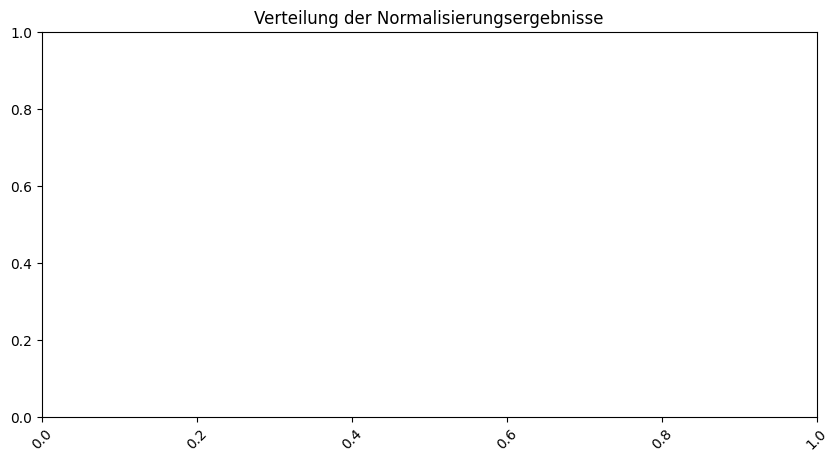

In [14]:
import pandas as pd

# Lade die Datei
df = pd.read_csv(r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\normalization_evaluation_results_all.csv")

# Zeige die ersten Zeilen
print(df.head())

# Zeige grundlegende Statistiken
print(df.describe())

# Welche Normalisierung hat die höchste Verbesserung?
#print(df.groupby("Normalization Method").mean())

# Falls du eine Visualisierung möchtest
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=df.iloc[:, 1:])  # Erster Spaltenindex ignorieren, falls es eine ID-Spalte gibt
plt.title("Verteilung der Normalisierungsergebnisse")
plt.xticks(rotation=45)
plt.show()


In [15]:
import pandas as pd

# 📌 Lade die Datei
file_path = r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\normalization_evaluation_results_all.csv"

# 🔹 Versuche, die Datei mit verschiedenen Encodings zu laden
try:
    df = pd.read_csv(file_path)
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="latin1")  # Falls Probleme mit Sonderzeichen auftreten

# 📌 Zeige die ersten Zeilen
print("🔹 Erste Zeilen der Datei:")
print(df.head())

# 📌 Zeige die Spaltennamen
print("\n🔹 Spaltenübersicht:")
print(df.columns)

# 📌 Prüfe, ob die Datei unerwartete Zeilenumbrüche oder falsch gesetzte Trennzeichen enthält
print("\n🔹 Anzahl der Spalten:")
print(len(df.columns))

# 📌 Falls die Datei falsch formatiert ist, kann man sie in einem gut lesbaren Format speichern
formatted_file_path = file_path.replace(".csv", "_formatted.xlsx")
df.to_excel(formatted_file_path, index=False)

print(f"\n✅ Die formatierte Datei wurde gespeichert unter: {formatted_file_path}")

# 📌 OPTIONAL: Falls du es gleich in Excel automatisch öffnen willst
import os
os.system(f'start excel "{formatted_file_path}"')


🔹 Erste Zeilen der Datei:
     Unnamed: 0 dataset_imputed_gpr_10.csv dataset_imputed_gpr_10.csv.1  \
0           NaN                     minmax                       minmax   
1           NaN     Variance Reduction (%)           Skewness Reduction   
2        Gaze X          99.99997432618662      -1.1102230246251565e-16   
3        Gaze Y          99.99992678916134       -4.440892098500626e-16   
4  ET_PupilLeft          99.18702586524036       -2.220446049250313e-16   

  dataset_imputed_gpr_10.csv.2 dataset_imputed_gpr_10.csv.3  \
0                       minmax                       minmax   
1           Kurtosis Reduction            KS-Test Statistic   
2        4.440892098500626e-16           0.7680525164113785   
3                          0.0           0.5532458059810358   
4        8.881784197001252e-16           0.7419766593727206   

  dataset_imputed_gpr_10.csv.4 dataset_imputed_gpr_10.csv.5  \
0                       minmax                       zscore   
1              KS-

0

In [16]:
import pandas as pd

# Lade die große Datei
df = pd.read_excel("C:/Users/oxije/Dropbox/Dissertation/konferenzen/sigmod/mv/normalization_evaluation_results_all_formatted.xlsx")

# Speichere die ersten 100 Zeilen als kleine Datei zum Hochladen
df.head(100).to_csv("normalization_results_small.csv", index=False)


✅ Kombinierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_knn_mad.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_knn_mad_normalized_minmax.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_knn_mad_normalized_zscore.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_knn_mad_normalized_robust.csv
✅ Kombinierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_knn_isolationforest.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_knn_isolationforest_normalized_minmax.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_knn_isolationforest_normalized_zscore.csv
✅ Normalisierte Datei ge

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\728694476.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  "locf": lambda df: df.fillna(method='ffill').fillna(method='bfill')  # Falls am Anfang/Ende noch NaNs sind


✅ Kombinierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_mad.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_mad_normalized_minmax.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_mad_normalized_zscore.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_mad_normalized_robust.csv


C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\728694476.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  "locf": lambda df: df.fillna(method='ffill').fillna(method='bfill')  # Falls am Anfang/Ende noch NaNs sind


✅ Kombinierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_isolationforest.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_isolationforest_normalized_minmax.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_isolationforest_normalized_zscore.csv
✅ Normalisierte Datei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\combined\dataset_locf_isolationforest_normalized_robust.csv
✅ Evaluationsdatei gespeichert: C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv\normalization_evaluation_results.csv


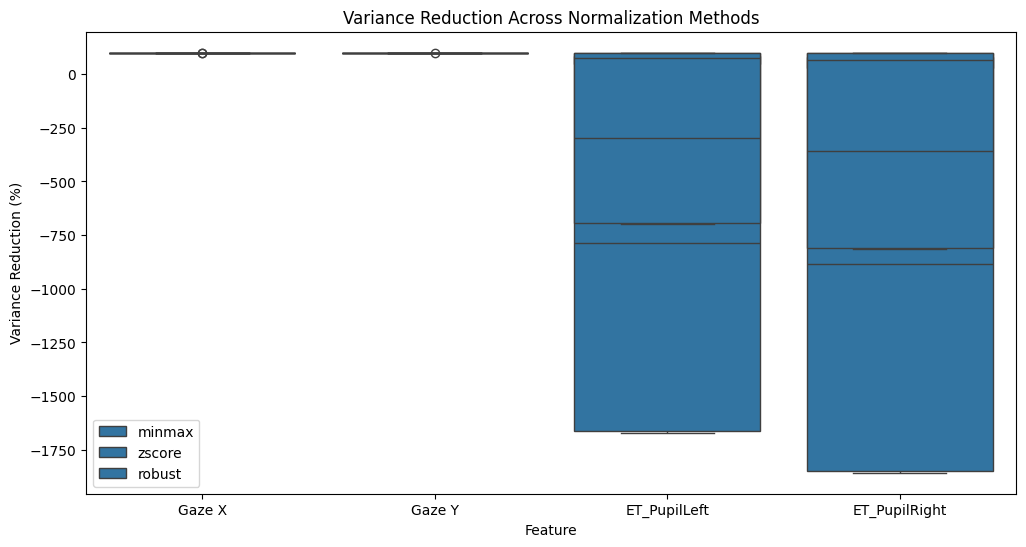

🎉 Normalization Experiment completed successfully!


In [44]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, skew, kurtosis
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest

# 🔹 Pfad zum Dataset-Ordner
dataset_dir = r"C:\Users\oxije\Dropbox\Dissertation\konferenzen\sigmod\mv"

# 🔹 Originaldatensatz laden
original_file = os.path.join(dataset_dir, "Frage 1_001_Anonymous 09-05-23 12h04m.csv")
df_original = pd.read_csv(original_file)

# 🔹 Gaze-Feature-Spalten
gaze_cols = ["Gaze X", "Gaze Y", "ET_PupilLeft", "ET_PupilRight"]

# 🔹 Methoden für MV-Imputation und Outlier-Erkennung
mv_methods = {
    "knn": lambda df: pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(df), columns=df.columns),
    "locf": lambda df: df.fillna(method='ffill').fillna(method='bfill')  # Falls am Anfang/Ende noch NaNs sind
}

outlier_methods = {
    "mad": lambda df: df.apply(lambda x: np.where(
        np.abs(x - np.median(x)) > 3 * np.median(np.abs(x - np.median(x))), np.nan, x), axis=0),
    "isolationforest": lambda df: df.apply(lambda x: pd.Series(
        np.where(IsolationForest(contamination=0.05, random_state=42).fit_predict(
            x.fillna(x.median()).values.reshape(-1, 1)) == -1, np.nan, x)), axis=0)  # NaN ersetzen
}

# 🔹 Normalisierungs-Methoden definieren
scalers = {
    "minmax": MinMaxScaler(),
    "zscore": StandardScaler(),
    "robust": RobustScaler()
}

# 🔹 Speicherordner für Ergebnisse
combined_dir = os.path.join(dataset_dir, "combined")
os.makedirs(combined_dir, exist_ok=True)

# 🔹 Liste zur Speicherung der Evaluationsdaten
evaluation_results = []

# 🔹 Erstelle die vier Kombinationen und normalisiere
for mv_name, mv_imputer in mv_methods.items():
    for outlier_name, outlier_method in outlier_methods.items():
        df_combined = df_original.copy()

        # 🔹 MV-Imputation anwenden
        df_combined[gaze_cols] = mv_imputer(df_combined[gaze_cols])

        # 🔹 Outlier-Erkennung anwenden
        df_combined[gaze_cols] = outlier_method(df_combined[gaze_cols])

        # 🔹 Datei speichern
        combined_file = os.path.join(combined_dir, f"dataset_{mv_name}_{outlier_name}.csv")
        df_combined.to_csv(combined_file, index=False)
        print(f"✅ Kombinierte Datei gespeichert: {combined_file}")

        # 🔹 Normalisierung und Evaluierung
        for norm_name, scaler in scalers.items():
            df_normalized = df_combined.copy()
            df_normalized[gaze_cols] = scaler.fit_transform(df_combined[gaze_cols])

            # 🔹 Speichern der normalisierten Datei
            norm_file = combined_file.replace(".csv", f"_normalized_{norm_name}.csv")
            df_normalized.to_csv(norm_file, index=False)
            print(f"✅ Normalisierte Datei gespeichert: {norm_file}")

            # 🔹 Berechnung der Evaluationsmetriken
            for col in gaze_cols:
                original_var = np.var(df_combined[col].dropna())
                normalized_var = np.var(df_normalized[col].dropna())
                original_skew = skew(df_combined[col].dropna())
                normalized_skew = skew(df_normalized[col].dropna())
                original_kurt = kurtosis(df_combined[col].dropna())
                normalized_kurt = kurtosis(df_normalized[col].dropna())

                ks_stat, ks_pval = ks_2samp(df_combined[col].dropna(), df_normalized[col].dropna())

                evaluation_results.append({
                    "MV Method": mv_name,
                    "Outlier Method": outlier_name,
                    "Normalization": norm_name,
                    "Feature": col,
                    "Variance Reduction (%)": (original_var - normalized_var) / original_var * 100,
                    "Skewness Reduction": abs(original_skew) - abs(normalized_skew),
                    "Kurtosis Reduction": abs(original_kurt) - abs(normalized_kurt),
                    "KS-Test Statistic": ks_stat,
                    "KS-Test P-Value": ks_pval
                })

# 🔹 Evaluationsergebnisse speichern
df_eval = pd.DataFrame(evaluation_results)
eval_file = os.path.join(dataset_dir, "normalization_evaluation_results.csv")
df_eval.to_csv(eval_file, index=False)
print(f"✅ Evaluationsdatei gespeichert: {eval_file}")

# 🔹 Boxplot-Visualisierung
plt.figure(figsize=(12, 6))
for norm_name in scalers.keys():
    df_plot = df_eval[df_eval["Normalization"] == norm_name]
    sns.boxplot(x="Feature", y="Variance Reduction (%)", hue="Normalization", data=df_plot)
plt.title("Variance Reduction Across Normalization Methods")
plt.legend()
plt.show()

print("🎉 Normalization Experiment completed successfully!")


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ace_tools as tools  

# Datei laden
file_path = "/mnt/data/normalization_evaluation_results.csv"
df_norm = pd.read_csv(file_path)

# Spaltennamen bereinigen (falls notwendig)
df_norm.columns = [col.strip() for col in df_norm.columns]

# Umwandlung in numerische Werte, falls notwendig
numeric_cols = ["Variance Reduction (%)", "Skewness Reduction", "Kurtosis Reduction", "KS-Test Statistic", "KS-Test P-Value"]
df_norm[numeric_cols] = df_norm[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 1. Balkendiagramm - Durchschnittliche Varianzreduktion nach Normalisierungsmethode
plt.figure(figsize=(12, 6))
sns.barplot(data=df_norm, x="Normalization", y="Variance Reduction (%)", ci="sd")
plt.title("Durchschnittliche Varianzreduktion nach Normalisierungsmethode")
plt.xticks(rotation=45)
plt.xlabel("Normalization Method")
plt.ylabel("Variance Reduction (%)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 2. Boxplot - Verteilung der Skewness Reduction nach Normalisierungsmethode
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_norm, x="Normalization", y="Skewness Reduction")
plt.title("Verteilung der Skewness Reduction nach Normalisierungsmethode")
plt.xticks(rotation=45)
plt.xlabel("Normalization Method")
plt.ylabel("Skewness Reduction")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 3. Scatterplot - Skewness Reduction vs. Kurtosis Reduction
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_norm, x="Skewness Reduction", y="Kurtosis Reduction", hue="Normalization")
plt.title("Zusammenhang zwischen Skewness Reduction und Kurtosis Reduction")
plt.xlabel("Skewness Reduction")
plt.ylabel("Kurtosis Reduction")
plt.axhline(0, color='red', linestyle="--", alpha=0.5)
plt.axvline(0, color='red', linestyle="--", alpha=0.5)
plt.grid(True)
plt.show()

# 4. Heatmap - Korrelation der Evaluationsmetriken
plt.figure(figsize=(8, 6))
correlation_matrix = df_norm[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelation zwischen Evaluationsmetriken")
plt.show()


ModuleNotFoundError: No module named 'ace_tools'

C:\Users\oxije\AppData\Local\Temp\ipykernel_36552\351537371.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_norm, x="Normalization", y="Variance Reduction (%)", ci="sd")


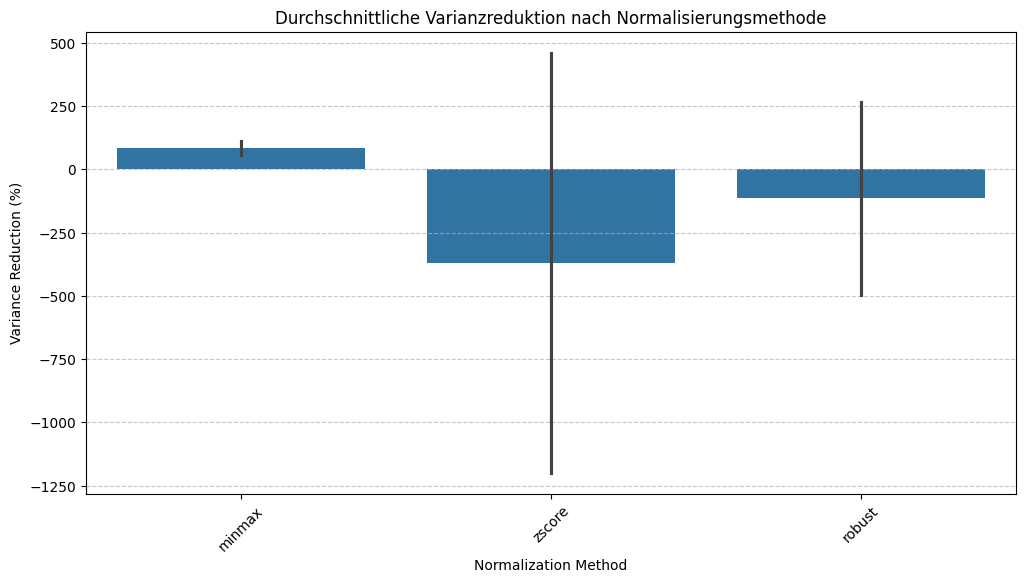

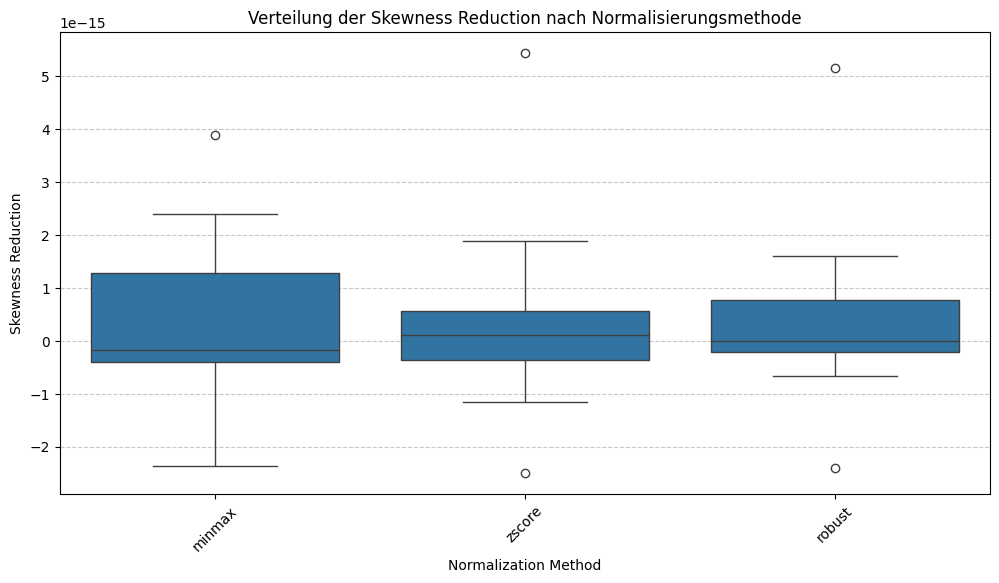

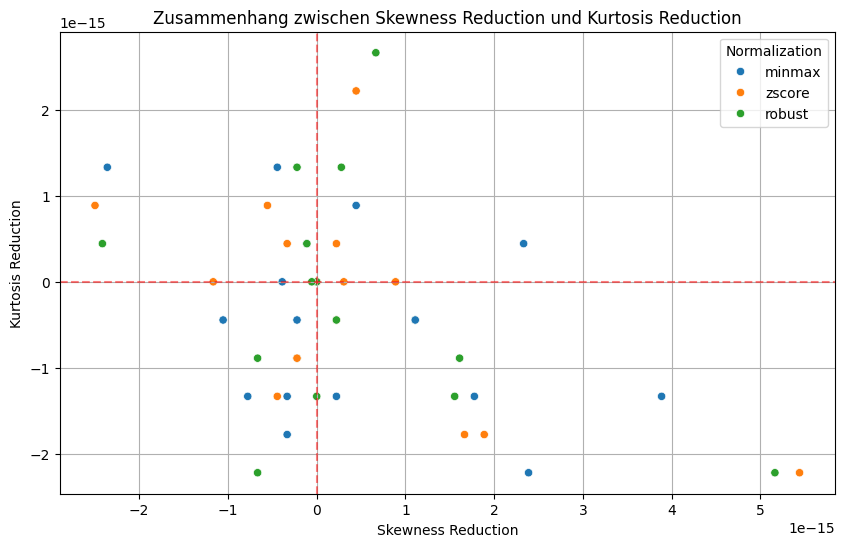

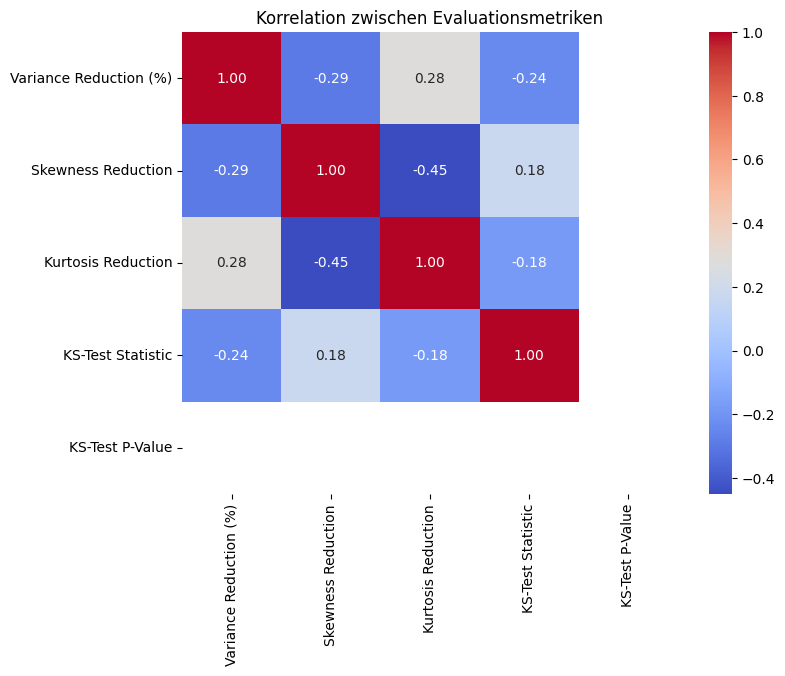

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datei laden
file_path = "normalization_evaluation_results.csv"  # Ersetze durch deinen Dateipfad
df_norm = pd.read_csv(file_path)

# Spalten bereinigen (falls notwendig)
df_norm.columns = [col.strip() for col in df_norm.columns]

# Umwandlung in numerische Werte
numeric_cols = ["Variance Reduction (%)", "Skewness Reduction", "Kurtosis Reduction", "KS-Test Statistic", "KS-Test P-Value"]
df_norm[numeric_cols] = df_norm[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 1. Balkendiagramm - Durchschnittliche Varianzreduktion nach Normalisierungsmethode
plt.figure(figsize=(12, 6))
sns.barplot(data=df_norm, x="Normalization", y="Variance Reduction (%)", ci="sd")
plt.title("Durchschnittliche Varianzreduktion nach Normalisierungsmethode")
plt.xticks(rotation=45)
plt.xlabel("Normalization Method")
plt.ylabel("Variance Reduction (%)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 2. Boxplot - Verteilung der Skewness Reduction nach Normalisierungsmethode
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_norm, x="Normalization", y="Skewness Reduction")
plt.title("Verteilung der Skewness Reduction nach Normalisierungsmethode")
plt.xticks(rotation=45)
plt.xlabel("Normalization Method")
plt.ylabel("Skewness Reduction")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 3. Scatterplot - Skewness Reduction vs. Kurtosis Reduction
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_norm, x="Skewness Reduction", y="Kurtosis Reduction", hue="Normalization")
plt.title("Zusammenhang zwischen Skewness Reduction und Kurtosis Reduction")
plt.xlabel("Skewness Reduction")
plt.ylabel("Kurtosis Reduction")
plt.axhline(0, color='red', linestyle="--", alpha=0.5)
plt.axvline(0, color='red', linestyle="--", alpha=0.5)
plt.grid(True)
plt.show()

# 4. Heatmap - Korrelation der Evaluationsmetriken
plt.figure(figsize=(8, 6))
correlation_matrix = df_norm[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelation zwischen Evaluationsmetriken")
plt.show()


In [53]:
import pandas as pd

# Daten als Liste von Dictionaries
data = [
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "Gaze X", "Variance Reduction (%)": 99.99979026416753, "Skewness Reduction": -1.0547118733938987e-15, "Kurtosis Reduction": -4.440892098500626e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "Gaze Y", "Variance Reduction (%)": 99.99931721640874, "Skewness Reduction": 2.3314683517128287e-15, "Kurtosis Reduction": 4.440892098500626e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 48.67977403964755, "Skewness Reduction": 3.885780586188048e-15, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "ET_PupilRight", "Variance Reduction (%)": 29.907859429406365, "Skewness Reduction": 2.3869795029440866e-15, "Kurtosis Reduction": -2.220446049250313e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "Gaze X", "Variance Reduction (%)": 99.99476017590442, "Skewness Reduction": -1.1657341758564144e-15, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "Gaze Y", "Variance Reduction (%)": 99.97789219091011, "Skewness Reduction": 8.881784197001252e-16, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "ET_PupilLeft", "Variance Reduction (%)": -1657.8597058645337, "Skewness Reduction": 5.440092820663267e-15, "Kurtosis Reduction": -2.220446049250313e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "ET_PupilRight", "Variance Reduction (%)": -1847.2710993322044, "Skewness Reduction": 1.887379141862766e-15, "Kurtosis Reduction": -1.7763568394002505e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "robust", "Feature": "Gaze X", "Variance Reduction (%)": 99.99609375, "Skewness Reduction": -6.661338147750939e-16, "Kurtosis Reduction": -8.881784197001252e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "robust", "Feature": "Gaze Y", "Variance Reduction (%)": 99.96932901076859, "Skewness Reduction": 1.1102230246251565e-15, "Kurtosis Reduction": -4.440892098500626e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "robust", "Feature": "ET_PupilLeft", "Variance Reduction (%)": -692.7626198359773, "Skewness Reduction": 5.162537064506978e-15, "Kurtosis Reduction": -2.220446049250313e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "mad", "Normalization": "robust", "Feature": "ET_PupilRight", "Variance Reduction (%)": -813.6107079683073, "Skewness Reduction": 1.5543122344752192e-15, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "Gaze X", "Variance Reduction (%)": 99.99992484380194, "Skewness Reduction": 4.440892098500626e-16, "Kurtosis Reduction": 8.881784197001252e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "Gaze Y", "Variance Reduction (%)": 99.99972351399555, "Skewness Reduction": -3.3306690738754696e-16, "Kurtosis Reduction": -1.7763568394002505e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 97.14513720056654, "Skewness Reduction": -4.440892098500626e-16, "Kurtosis Reduction": 1.3322676295501878e-15, "KS-Test Statistic": 0.7337300825494337, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "ET_PupilRight", "Variance Reduction (%)": 96.6541050160918, "Skewness Reduction": 2.220446049250313e-16, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 0.7288948580199539, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "Gaze X", "Variance Reduction (%)": 99.99798870881138, "Skewness Reduction": 0.0, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "Gaze Y", "Variance Reduction (%)": 99.99473177769387, "Skewness Reduction": -3.3306690738754696e-16, "Kurtosis Reduction": 4.440892098500626e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 82.68916424592531, "Skewness Reduction": 2.220446049250313e-16, "Kurtosis Reduction": 4.440892098500626e-16, "KS-Test Statistic": 0.7337300825494337, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "ET_PupilRight", "Variance Reduction (%)": 80.00001783508968, "Skewness Reduction": 2.220446049250313e-16, "Kurtosis Reduction": -4.440892098500626e-16, "KS-Test Statistic": 0.7288948580199539, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "Gaze X", "Variance Reduction (%)": 99.99840797009969, "Skewness Reduction": 6.661338147750939e-16, "Kurtosis Reduction": 2.6645352591003757e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "Gaze Y", "Variance Reduction (%)": 99.98441398937969, "Skewness Reduction": 2.7755575615628914e-16, "Kurtosis Reduction": 1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 96.68914648493511, "Skewness Reduction": -2.220446049250313e-16, "Kurtosis Reduction": 1.3322676295501878e-15, "KS-Test Statistic": 0.7337300825494337, "KS-Test P-Value": 0.0},
    {"MV Method": "knn", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "ET_PupilRight", "Variance Reduction (%)": 96.13631273099863, "Skewness Reduction": -2.220446049250313e-16, "Kurtosis Reduction": -8.881784197001252e-16, "KS-Test Statistic": 0.7288948580199539, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "Gaze X", "Variance Reduction (%)": 99.99991216428091, "Skewness Reduction": 1.1102230246251565e-15, "Kurtosis Reduction": -4.440892098500626e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "Gaze Y", "Variance Reduction (%)": 99.99985776913014, "Skewness Reduction": -3.885780586188048e-16, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 43.18138829604834, "Skewness Reduction": 1.7763568394002505e-15, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "minmax", "Feature": "ET_PupilRight", "Variance Reduction (%)": 25.468648929859445, "Skewness Reduction": -2.3592239273284576e-15, "Kurtosis Reduction": 1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "Gaze X", "Variance Reduction (%)": 99.99828596345239, "Skewness Reduction": 3.0531133177191805e-16, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "Gaze Y", "Variance Reduction (%)": 99.99692182323847, "Skewness Reduction": 0.0, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "ET_PupilLeft", "Variance Reduction (%)": -1672.134201815232, "Skewness Reduction": 1.6653345369377348e-15, "Kurtosis Reduction": -1.7763568394002505e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "zscore", "Feature": "ET_PupilRight", "Variance Reduction (%)": -1856.9552224154802, "Skewness Reduction": -2.4980018054066022e-15, "Kurtosis Reduction": 8.881784197001252e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "robust", "Feature": "Gaze X", "Variance Reduction (%)": 99.99925144237697, "Skewness Reduction": 0.0, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "robust", "Feature": "Gaze Y", "Variance Reduction (%)": 99.9984190285721, "Skewness Reduction": -5.551115123125783e-17, "Kurtosis Reduction": 0.0, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "robust", "Feature": "ET_PupilLeft", "Variance Reduction (%)": -699.6186168091458, "Skewness Reduction": 1.609823385706477e-15, "Kurtosis Reduction": -8.881784197001252e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "mad", "Normalization": "robust", "Feature": "ET_PupilRight", "Variance Reduction (%)": -810.5005461126362, "Skewness Reduction": -2.4147350785597155e-15, "Kurtosis Reduction": 4.440892098500626e-16, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "Gaze X", "Variance Reduction (%)": 99.99994752805314, "Skewness Reduction": -7.771561172376096e-16, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "Gaze Y", "Variance Reduction (%)": 99.9998938282635, "Skewness Reduction": -3.3306690738754696e-16, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 97.13643214108448, "Skewness Reduction": -2.220446049250313e-16, "Kurtosis Reduction": -4.440892098500626e-16, "KS-Test Statistic": 0.7291226722979459, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "minmax", "Feature": "ET_PupilRight", "Variance Reduction (%)": 96.62132998838224, "Skewness Reduction": -1.1102230246251565e-16, "Kurtosis Reduction": 4.440892098500626e-16, "KS-Test Statistic": 0.7245681381957774, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "Gaze X", "Variance Reduction (%)": 99.99865707037688, "Skewness Reduction": -4.440892098500626e-16, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "Gaze Y", "Variance Reduction (%)": 99.99747519209609, "Skewness Reduction": 4.440892098500626e-16, "Kurtosis Reduction": 2.220446049250313e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 82.8808533316429, "Skewness Reduction": -2.220446049250313e-16, "Kurtosis Reduction": -8.881784197001252e-16, "KS-Test Statistic": 0.7291226722979459, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "zscore", "Feature": "ET_PupilRight", "Variance Reduction (%)": 80.18972576386734, "Skewness Reduction": -5.551115123125783e-16, "Kurtosis Reduction": 8.881784197001252e-16, "KS-Test Statistic": 0.7245681381957774, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "Gaze X", "Variance Reduction (%)": 99.99933402705516, "Skewness Reduction": -6.661338147750939e-16, "Kurtosis Reduction": -2.220446049250313e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "Gaze Y", "Variance Reduction (%)": 99.99848006414129, "Skewness Reduction": 0.0, "Kurtosis Reduction": -1.3322676295501878e-15, "KS-Test Statistic": 1.0, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "ET_PupilLeft", "Variance Reduction (%)": 96.68708642124287, "Skewness Reduction": 2.220446049250313e-16, "Kurtosis Reduction": -4.440892098500626e-16, "KS-Test Statistic": 0.7291226722979459, "KS-Test P-Value": 0.0},
    {"MV Method": "locf", "Outlier Method": "isolationforest", "Normalization": "robust", "Feature": "ET_PupilRight", "Variance Reduction (%)": 96.13355901781088, "Skewness Reduction": -1.1102230246251565e-16, "Kurtosis Reduction": 4.440892098500626e-16, "KS-Test Statistic": 0.7245681381957774, "KS-Test P-Value": 0.0}
]

# DataFrame erstellen
df = pd.DataFrame(data)

# Excel-Datei speichern
df.to_excel("output.xlsx", index=False)

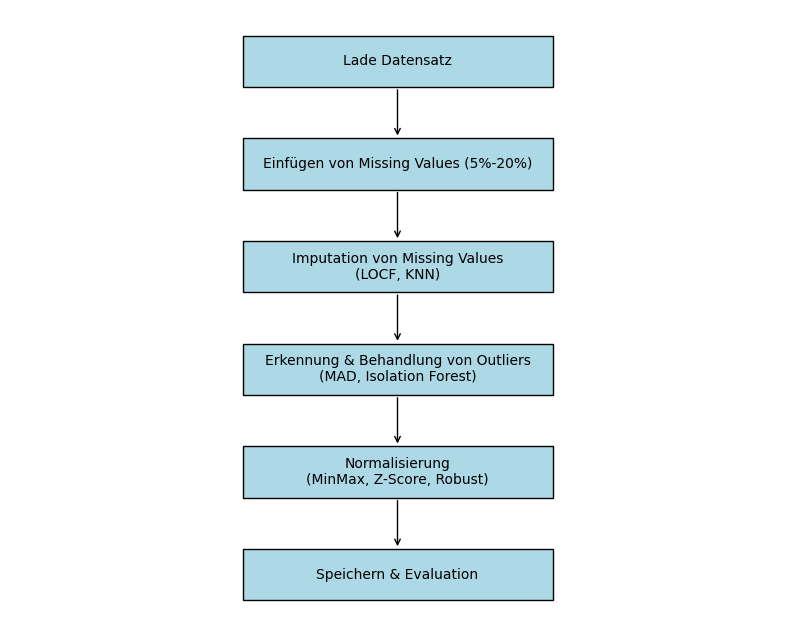

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Erstellen des Diagramms
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Elemente im Diagramm
steps = [
    (5, 11, "Lade Datensatz"),
    (5, 9, "Einfügen von Missing Values (5%-20%)"),
    (5, 7, "Imputation von Missing Values\n(LOCF, KNN)"),
    (5, 5, "Erkennung & Behandlung von Outliers\n(MAD, Isolation Forest)"),
    (5, 3, "Normalisierung\n(MinMax, Z-Score, Robust)"),
    (5, 1, "Speichern & Evaluation")
]

# Rechtecke zeichnen
for x, y, text in steps:
    ax.add_patch(mpatches.Rectangle((x-2, y-0.5), 4, 1, facecolor="lightblue", edgecolor="black"))
    ax.text(x, y, text, ha="center", va="center", fontsize=10)

# Pfeile zeichnen
for i in range(len(steps) - 1):
    x1, y1, _ = steps[i]
    x2, y2, _ = steps[i + 1]
    ax.annotate("", xy=(x2, y2+0.5), xytext=(x1, y1-0.5),
                arrowprops=dict(arrowstyle="->", color="black"))

# Diagramm anzeigen
plt.show()
